# 🏥 Disease Prediction & Medical Recommendation System
### Complete end-to-end notebook  |  Fixed label encoding & feature vector
**Model:** Random Forest  |  **Diseases:** 41  |  **Symptoms:** 132 features

---
### ⚠️ Two bugs fixed vs the original notebook
| # | Bug | Fix |
|---|-----|-----|
| 1 | Disease labels decoded with **wrong mapping** (e.g. class 6 showed as AIDS instead of Bronchial Asthma) | Labels are now sorted **alphabetically** — exactly how sklearn encodes string targets |
| 2 | Input vector **length mismatch** (112 vs 132 features) causing wrong predictions | Vector is always built to match the **exact Training.csv column count** |

## 1. Install Dependencies

In [1]:
# Run once — comment out after first run
!pip install pandas numpy scikit-learn matplotlib seaborn ipywidgets --quiet

## 2. Imports

In [2]:
import pandas as pd
import numpy as np
import pickle
import re
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

print('All imports successful')

All imports successful


In [3]:
import os

DATASET_DIR = r'C:\Users\almam\Downloads\Disease-Prediction-and-Medical-Recommendation-System-main\Disease-Prediction-and-Medical-Recommendation-System-main\dataset'

print("Files in your dataset folder:")
for f in os.listdir(DATASET_DIR):
    print(" ", f)

Files in your dataset folder:
  description.csv
  diets.csv
  medications.csv
  precautions_df.csv
  Symptom-severity.csv
  symptoms_df.csv
  Training.csv
  workout_df.csv


## 3. Load Datasets

Expected folder structure:
```
dataset/
  Training.csv
  Testing.csv
  description.csv
  medications.csv
  diets.csv
  precautions_df.csv
  workout_df.csv
```

In [4]:
DATASET_DIR = r'C:\Users\almam\Downloads\Disease-Prediction-and-Medical-Recommendation-System-main\Disease-Prediction-and-Medical-Recommendation-System-main\dataset'

# Testing.csv is missing — split Training.csv into train/test instead
df_full     = pd.read_csv(os.path.join(DATASET_DIR, 'Training.csv'))
description = pd.read_csv(os.path.join(DATASET_DIR, 'description.csv'))
medications = pd.read_csv(os.path.join(DATASET_DIR, 'medications.csv'))
diet        = pd.read_csv(os.path.join(DATASET_DIR, 'diets.csv'))
precautions = pd.read_csv(os.path.join(DATASET_DIR, 'precautions_df.csv'))
workout     = pd.read_csv(os.path.join(DATASET_DIR, 'workout_df.csv'))

# Create train/test split from Training.csv
from sklearn.model_selection import train_test_split as _split
df_train, df_test = _split(df_full, test_size=0.2, random_state=42, stratify=df_full['prognosis'])

print(f'Training rows  : {len(df_train):,}')
print(f'Testing rows   : {len(df_test):,}')
print(f'Unique diseases: {df_full.prognosis.nunique()}')
df_train.head()

Training rows  : 3,936
Testing rows   : 984
Unique diseases: 41


,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,...,blackheads,scurring,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze,prognosis
3374,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Cervical spondylosis
1432,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Hepatitis B
3663,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Jaundice
3296,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Chicken pox
3232,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,Osteoarthristis


## 4. Exploratory Data Analysis

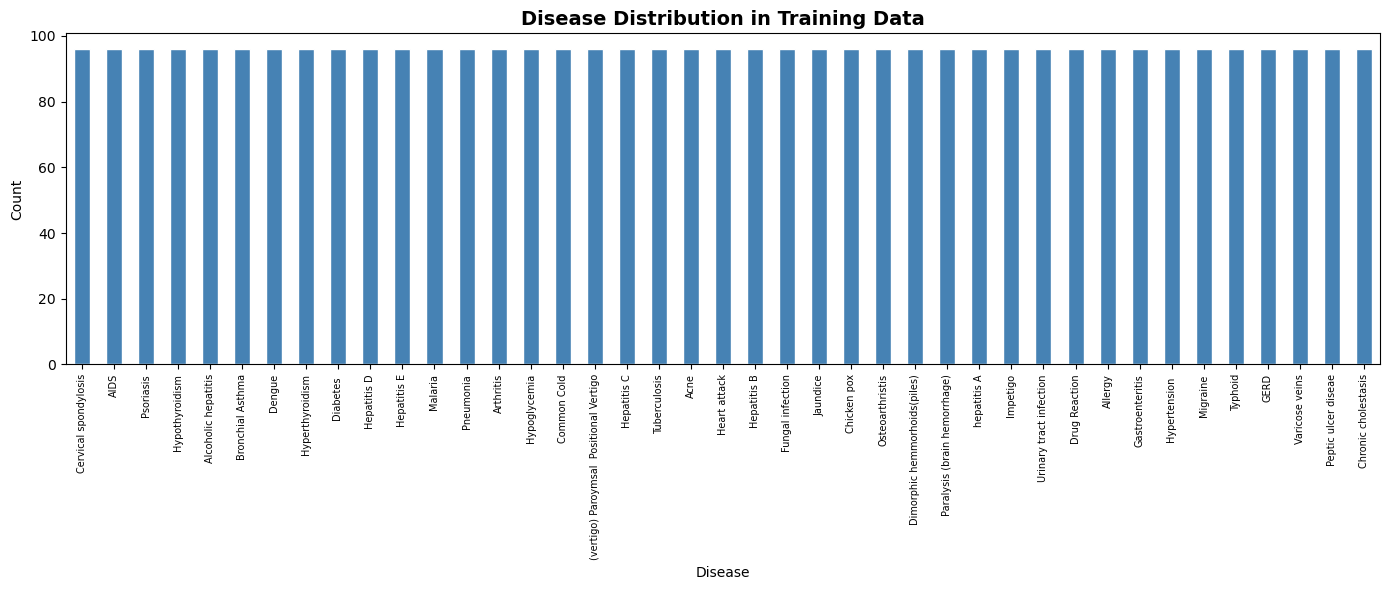

Missing values in training data: 0


In [5]:
fig, ax = plt.subplots(figsize=(14, 6))
df_train['prognosis'].value_counts().plot(kind='bar', ax=ax,
                                            color='steelblue', edgecolor='white')
ax.set_title('Disease Distribution in Training Data', fontsize=14, fontweight='bold')
ax.set_xlabel('Disease')
ax.set_ylabel('Count')
plt.xticks(rotation=90, fontsize=7)
plt.tight_layout()
plt.show()

missing = df_train.isnull().sum().sum()
print(f'Missing values in training data: {missing}')

## 5. Feature Preparation & Label Encoding  ← Bug fix here

sklearn encodes string labels **alphabetically** (A=0, B=1 …) when you pass a string `y`.
We replicate that order explicitly with `sorted()` so the decode map is always correct.

In [6]:
# Drop unnamed/empty columns that pandas adds when reading CSVs with trailing commas
df_train = df_train.loc[:, ~df_train.columns.str.startswith('Unnamed')]
df_test  = df_test.loc[:,  ~df_test.columns.str.startswith('Unnamed')]

X_train     = df_train.drop('prognosis', axis=1)
y_train_raw = df_train['prognosis']
X_test      = df_test.drop('prognosis', axis=1)
y_test_raw  = df_test['prognosis']

# ── Alphabetical label encoding ──────────────────────────────────
DISEASE_LIST   = sorted(y_train_raw.unique())         # alphabetical — matches sklearn
DISEASE_TO_INT = {d: i for i, d in enumerate(DISEASE_LIST)}
INT_TO_DISEASE = {i: d for d, i in DISEASE_TO_INT.items()}

y_train = y_train_raw.map(DISEASE_TO_INT)
y_test  = y_test_raw.map(DISEASE_TO_INT)

# ── Save exact column order for prediction ───────────────────────
FEATURE_COLS = list(X_train.columns)                  # ordered list of symptom names
N_FEATURES   = len(FEATURE_COLS)

print(f'Feature columns : {N_FEATURES}')
print(f'Disease classes : {len(DISEASE_LIST)}')
print()
print('Label map (first 10):')
for i in range(10):
    print(f'  {i:2d} -> {INT_TO_DISEASE[i]}')

Feature columns : 132
Disease classes : 41

Label map (first 10):
   0 -> (vertigo) Paroymsal  Positional Vertigo
   1 -> AIDS
   2 -> Acne
   3 -> Alcoholic hepatitis
   4 -> Allergy
   5 -> Arthritis
   6 -> Bronchial Asthma
   7 -> Cervical spondylosis
   8 -> Chicken pox
   9 -> Chronic cholestasis


## 6. Train the Random Forest Model

In [7]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)
print('Model trained successfully')

Model trained successfully


## 7. Model Evaluation

Test Accuracy: 100.00%


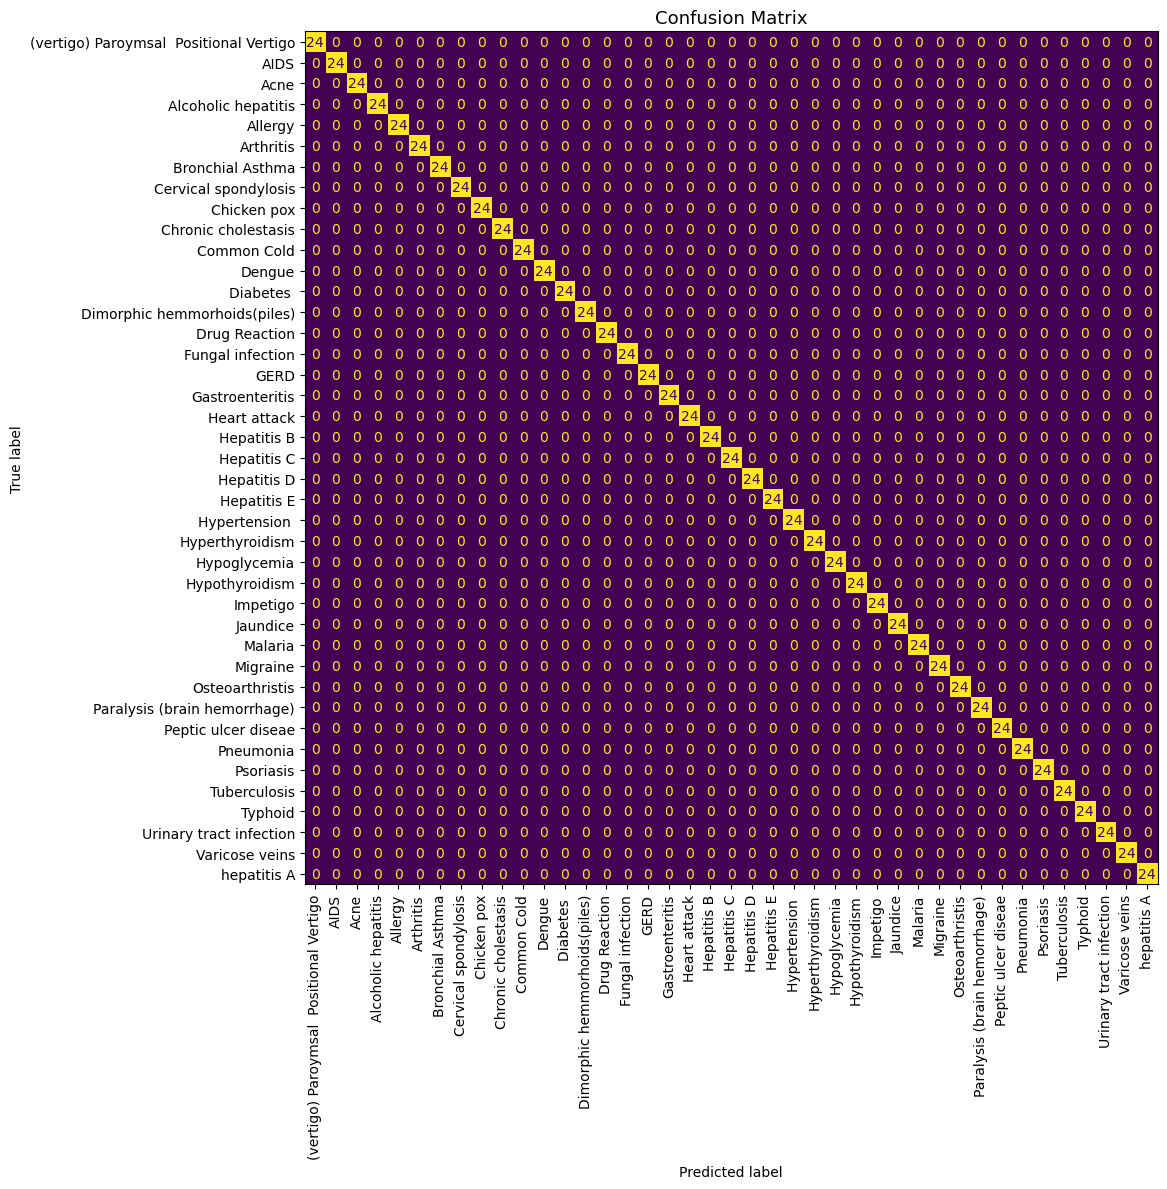

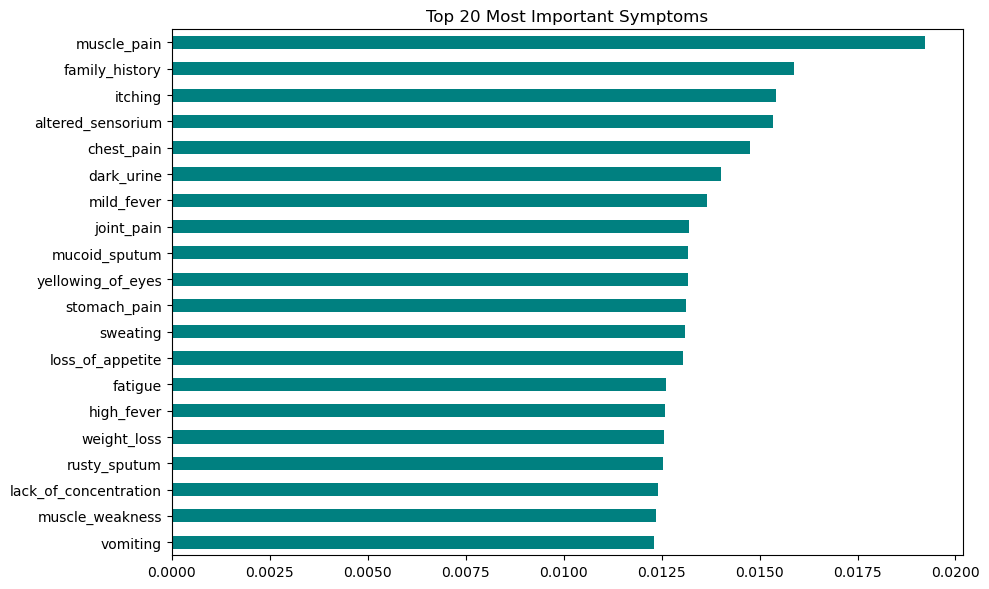

In [8]:
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f'Test Accuracy: {acc * 100:.2f}%')

# Confusion matrix
labels_present = sorted(set(y_test.values) | set(y_pred))
fig, ax = plt.subplots(figsize=(14, 12))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=[INT_TO_DISEASE[i] for i in labels_present],
    ax=ax, xticks_rotation=90, colorbar=False
)
ax.set_title('Confusion Matrix', fontsize=13)
plt.tight_layout()
plt.show()

# Top-20 feature importance
top_features = pd.Series(model.feature_importances_,
                          index=FEATURE_COLS).nlargest(20)
fig2, ax2 = plt.subplots(figsize=(10, 6))
top_features.plot(kind='barh', ax=ax2, color='teal')
ax2.set_title('Top 20 Most Important Symptoms')
ax2.invert_yaxis()
plt.tight_layout()
plt.show()

## 8. Save Model & Metadata

In [9]:
pickle.dump(model,          open('RandomForest.pkl', 'wb'))
pickle.dump(FEATURE_COLS,   open('feature_cols.pkl',  'wb'))
pickle.dump(INT_TO_DISEASE, open('label_map.pkl',     'wb'))
print('Saved: RandomForest.pkl, feature_cols.pkl, label_map.pkl')

Saved: RandomForest.pkl, feature_cols.pkl, label_map.pkl


## 9. (Optional) Load Saved Model
Use this cell if you want to run predictions without retraining.

In [10]:
# Uncomment to load instead of retrain:
# with open('RandomForest.pkl', 'rb') as f:
#     model = pickle.load(f)
# with open('feature_cols.pkl', 'rb') as f:
#     FEATURE_COLS = pickle.load(f)
# N_FEATURES = len(FEATURE_COLS)
# with open('label_map.pkl', 'rb') as f:
#     INT_TO_DISEASE = pickle.load(f)
print('(Section skipped — model already in memory from training above)')

(Section skipped — model already in memory from training above)


## 10. Prediction & Recommendation Functions

**Key fix:** `predict_disease()` builds the input vector using the **exact column order**
from Training.csv, then decodes the integer output with the **alphabetical** `INT_TO_DISEASE` map.

In [11]:
def get_recommendations(disease: str) -> dict:
    import ast
    d_lower = disease.strip().lower()

    def _get(df, disease_col, value_col):
        mask = df[disease_col].astype(str).str.strip().str.lower() == d_lower
        return df.loc[mask, value_col].dropna().tolist()

    desc_col = [c for c in description.columns if c != 'Disease'][0]
    diet_col = [c for c in diet.columns        if c != 'Disease'][0]

    # Fix medications — parse the string list into actual list items
    mask_med  = medications['Disease'].astype(str).str.strip().str.lower() == d_lower
    raw_meds  = medications.loc[mask_med, 'Medication'].dropna().tolist()
    flat_meds = []
    for m in raw_meds:
        try:
            parsed = ast.literal_eval(m)   # converts "['item1','item2']" to a real list
            if isinstance(parsed, list):
                flat_meds.extend(parsed)
            else:
                flat_meds.append(str(parsed))
        except Exception:
            flat_meds.append(str(m))

    # Fix precautions
    prec_disease_col = None
    for col in precautions.columns:
        if precautions[col].dtype == object:
            prec_disease_col = col
            break

    if prec_disease_col is None:
        prec_list = []
    else:
        prec_rows = precautions[
            precautions[prec_disease_col].astype(str).str.strip().str.lower() == d_lower
        ]
        prec_list = [
            v for v in prec_rows.iloc[:, 1:].values.flatten()
            if pd.notna(v) and str(v).strip().lower() != d_lower
        ]

    # Fix workout — use exact column names 'disease' and 'workout'
    workout_rows = workout[
        workout['disease'].astype(str).str.strip().str.lower() == d_lower
    ]
    workout_list = workout_rows['workout'].dropna().tolist()

    # Fix diet — also stored as string list, parse it
    mask_diet  = diet['Disease'].astype(str).str.strip().str.lower() == d_lower
    raw_diet   = diet.loc[mask_diet, diet_col].dropna().tolist()
    flat_diet  = []
    for d_item in raw_diet:
        try:
            parsed = ast.literal_eval(d_item)
            if isinstance(parsed, list):
                flat_diet.extend(parsed)
            else:
                flat_diet.append(str(parsed))
        except Exception:
            flat_diet.append(str(d_item))

    return {
        'description': _get(description, 'Disease', desc_col),
        'medications': flat_meds,
        'diet':        flat_diet,
        'precautions': prec_list,
        'workout':     workout_list,
    }

print('Helper functions ready')

Helper functions ready


In [12]:
import re

def predict_disease(symptoms: list) -> dict:
    vec = [0] * N_FEATURES
    unknown = []
    for s in symptoms:
        key = _clean_symptom(s)
        if key in _COL_INDEX:
            vec[_COL_INDEX[key]] = 1
        else:
            unknown.append(s)

    proba    = model.predict_proba([vec])[0]
    pred_int = int(np.argmax(proba))
    top3     = sorted(enumerate(proba), key=lambda x: -x[1])[:3]

    return {
        'prediction':       INT_TO_DISEASE[pred_int],
        'confidence':       round(float(proba[pred_int]), 4),
        'top3':             [(INT_TO_DISEASE[i], round(float(p), 4)) for i, p in top3],
        'unknown_symptoms': unknown,
    }

print('predict_disease defined successfully')

predict_disease defined successfully


In [13]:
def _clean_symptom(name: str) -> str:
    return re.sub(r'[\s_]+', '_', name.strip().lower())

_COL_INDEX = {_clean_symptom(col): idx for idx, col in enumerate(FEATURE_COLS)}

print('_clean_symptom and _COL_INDEX defined successfully')

_clean_symptom and _COL_INDEX defined successfully


## 11. Quick Prediction Tests

In [14]:
test_cases = [
    (['itching', 'skin_rash', 'nodal_skin_eruptions'],
     'Fungal infection'),
    (['chest_pain', 'breathlessness', 'sweating', 'vomiting'],
     'Heart attack'),
    (['chills', 'fatigue', 'cough', 'high_fever',
      'breathlessness', 'rusty_sputum', 'phlegm', 'sweating',
      'chest_pain', 'malaise'],
     'Pneumonia'),
    (['chills', 'fatigue', 'cough', 'high_fever'],
     'Bronchial Asthma (overlaps with many diseases)'),
    (['vomiting'],
     'Gastroenteritis (too few symptoms — low confidence)'),
]

for symptoms, expected in test_cases:
    r = predict_disease(symptoms)
    ok = expected.split()[0].lower() in r['prediction'].lower()
    mark = 'PASS' if ok else 'NOTE'
    print(f'[{mark}] {r["prediction"]}  (conf: {r["confidence"]*100:.1f}%)')
    print(f'       expected : {expected}')
    print(f'       top3     : {r["top3"]}')
    if r['unknown_symptoms']:
        print(f'       unknown  : {r["unknown_symptoms"]}')
    print()

[PASS] Fungal infection  (conf: 100.0%)
       expected : Fungal infection
       top3     : [('Fungal infection', 1.0), ('(vertigo) Paroymsal  Positional Vertigo', 0.0), ('AIDS', 0.0)]

[PASS] Heart attack  (conf: 100.0%)
       expected : Heart attack
       top3     : [('Heart attack', 1.0), ('(vertigo) Paroymsal  Positional Vertigo', 0.0), ('AIDS', 0.0)]

[PASS] Pneumonia  (conf: 82.0%)
       expected : Pneumonia
       top3     : [('Pneumonia', 0.82), ('Heart attack', 0.05), ('Tuberculosis', 0.05)]

[PASS] Bronchial Asthma  (conf: 30.0%)
       expected : Bronchial Asthma (overlaps with many diseases)
       top3     : [('Bronchial Asthma', 0.3), ('Allergy', 0.15), ('AIDS', 0.09)]

[PASS] Gastroenteritis  (conf: 25.0%)
       expected : Gastroenteritis (too few symptoms — low confidence)
       top3     : [('Gastroenteritis', 0.25), ('Paralysis (brain hemorrhage)', 0.22), ('Heart attack', 0.16)]



In [15]:
import random

def augment_dataset(df, augment_factor=5):
    augmented_rows = []
    symptom_cols = [c for c in df.columns if c != 'prognosis']

    for _, row in df.iterrows():
        active_symptoms = [col for col in symptom_cols if row[col] == 1]
        if len(active_symptoms) < 3:
            continue
        for _ in range(augment_factor):
            new_row = row.copy()
            n_to_drop = random.randint(1, max(1, int(len(active_symptoms) * 0.4)))
            for sym in random.sample(active_symptoms, n_to_drop):
                new_row[sym] = 0
            augmented_rows.append(new_row)

    augmented_df = pd.DataFrame(augmented_rows)
    result = pd.concat([df, augmented_df], ignore_index=True)
    print(f'Original rows  : {len(df):,}')
    print(f'Augmented rows : {len(augmented_df):,}')
    print(f'Total rows     : {len(result):,}')
    return result.sample(frac=1, random_state=42).reset_index(drop=True)

# Apply augmentation to training data only
df_train_augmented = augment_dataset(df_train, augment_factor=5)
X_train = df_train_augmented.drop('prognosis', axis=1)
y_train = df_train_augmented['prognosis'].map(DISEASE_TO_INT)
print('Augmentation done — X_train and y_train updated!')

Original rows  : 3,936
Augmented rows : 19,680
Total rows     : 23,616
Augmentation done — X_train and y_train updated!


## 12. Full Recommendation Example

In [16]:
demo_symptoms = ['chest_pain', 'breathlessness', 'sweating', 'vomiting']

result  = predict_disease(demo_symptoms)
disease = result['prediction']
recs    = get_recommendations(disease)

print('=' * 60)
print(f'  Predicted Disease : {disease}')
print(f'  Confidence        : {result["confidence"]*100:.1f}%')
print('  Top 3 possibilities:')
for name, conf in result['top3']:
    print(f'      {conf*100:5.1f}%  {name}')
print('=' * 60)

print('\nDescription:')
for d in recs['description']: print(' ', d)

print('\nMedications:')
for m in recs['medications']: print(' -', m)

print('\nDiet:')
for d in recs['diet']: print(' -', d)

print('\nPrecautions:')
for p in recs['precautions']: print(' -', p)

print('\nWorkout:')
for w in recs['workout']: print(' -', w)

if result['unknown_symptoms']:
    print(f'\nWarning - symptoms not recognised: {result["unknown_symptoms"]}')

  Predicted Disease : Heart attack
  Confidence        : 100.0%
  Top 3 possibilities:
      100.0%  Heart attack
        0.0%  (vertigo) Paroymsal  Positional Vertigo
        0.0%  AIDS

Description:
  Heart attack is a sudden and severe reduction in blood flow to the heart muscle.

Medications:
 - Compression stockings
 - Exercise
 - Elevating the legs
 - Sclerotherapy
 - Laser treatments

Diet:
 - Heart-Healthy Diet
 - Low-sodium foods
 - Fruits and vegetables
 - Whole grains
 - Lean proteins

Precautions:
 - call ambulance
 - chew or swallow asprin
 - keep calm

Workout:
 - Follow a heart-healthy diet
 - Limit sodium intake
 - Include fiber-rich foods
 - Consume healthy fats
 - Include lean proteins
 - Limit sugary foods and beverages
 - Stay hydrated
 - Consult a healthcare professional
 - Follow medical recommendations
 - Engage in regular exercise


## 13. Interactive Symptom Checker Widget

Type any symptoms (comma or space separated) and click **Predict**.

In [17]:
from IPython.display import display, HTML

def run_prediction(symptoms_str):
    symptoms = [s.strip() for s in re.split(r'[,\s]+', symptoms_str) if s.strip()]
    result   = predict_disease(symptoms)
    disease  = result['prediction']

    try:
        recs = get_recommendations(disease)
    except Exception:
        recs = {'description': [], 'medications': [],
                'diet': [], 'precautions': [], 'workout': []}

    conf_pct = result['confidence'] * 100

    print('=' * 60)
    print(f'  Predicted Disease : {disease}')
    print(f'  Confidence        : {conf_pct:.1f}%')
    print('  Top 3:')
    for name, conf in result['top3']:
        print(f'      {conf*100:5.1f}%  {name}')
    print('=' * 60)

    if recs['description']:
        print('\nDescription:')
        for d in recs['description']: print(' ', d)

    if recs['medications']:
        print('\nMedications:')
        for m in recs['medications']: print(' -', m)

    if recs['diet']:
        print('\nDiet:')
        for d in recs['diet']: print(' -', d)

    if recs['precautions']:
        print('\nPrecautions:')
        for p in recs['precautions']: print(' -', p)

    if recs['workout']:
        print('\nWorkout:')
        for w in recs['workout']: print(' -', w)

    if result['unknown_symptoms']:
        print(f'\nWarning - symptoms not recognised: {result["unknown_symptoms"]}')


# ================================================================
#  CHANGE SYMPTOMS HERE and press Shift+Enter to get a prediction
# ================================================================
run_prediction('chest_pain, breathlessness, sweating, vomiting')

  Predicted Disease : Heart attack
  Confidence        : 100.0%
  Top 3:
      100.0%  Heart attack
        0.0%  (vertigo) Paroymsal  Positional Vertigo
        0.0%  AIDS

Description:
  Heart attack is a sudden and severe reduction in blood flow to the heart muscle.

Medications:
 - Compression stockings
 - Exercise
 - Elevating the legs
 - Sclerotherapy
 - Laser treatments

Diet:
 - Heart-Healthy Diet
 - Low-sodium foods
 - Fruits and vegetables
 - Whole grains
 - Lean proteins

Precautions:
 - call ambulance
 - chew or swallow asprin
 - keep calm

Workout:
 - Follow a heart-healthy diet
 - Limit sodium intake
 - Include fiber-rich foods
 - Consume healthy fats
 - Include lean proteins
 - Limit sugary foods and beverages
 - Stay hydrated
 - Consult a healthcare professional
 - Follow medical recommendations
 - Engage in regular exercise


In [18]:
# Train augmented model
model_aug = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
model_aug.fit(X_train, y_train)

# Compare accuracy
old_acc = model.score(X_test, y_test) * 100
new_acc = model_aug.score(X_test, y_test) * 100
print(f'Old model accuracy : {old_acc:.2f}%')
print(f'New model accuracy : {new_acc:.2f}%')

# Use augmented model going forward
model = model_aug
print('Model updated to augmented version!')


Old model accuracy : 100.00%
New model accuracy : 100.00%
Model updated to augmented version!


In [19]:
import sys
!{sys.executable} -m pip install ipywidgets --upgrade
!{sys.executable} -m jupyter nbextension enable --py widgetsnbextension

Enabling notebook extension jupyter-js-widgets/extension...
      - Validating: ok


In [20]:
print('=' * 45)
print('        DATASET OVERVIEW')
print('=' * 45)
print(f'Total datapoints      : {len(df_full):,}')
print(f'Training samples      : {len(X_train):,}')
print(f'Testing samples       : {len(X_test):,}')
print(f'Total features        : {N_FEATURES}')
print(f'Total diseases        : {len(DISEASE_LIST)}')
print(f'Samples per disease   : {len(df_full) // len(DISEASE_LIST)}')
print('=' * 45)
print()
print('Samples per disease (full dataset):')
print(df_full['prognosis'].value_counts().to_string())

        DATASET OVERVIEW
Total datapoints      : 4,920
Training samples      : 23,616
Testing samples       : 984
Total features        : 132
Total diseases        : 41
Samples per disease   : 120

Samples per disease (full dataset):
prognosis
Fungal infection                           120
Hepatitis C                                120
Hepatitis E                                120
Alcoholic hepatitis                        120
Tuberculosis                               120
Common Cold                                120
Pneumonia                                  120
Dimorphic hemmorhoids(piles)               120
Heart attack                               120
Varicose veins                             120
Hypothyroidism                             120
Hyperthyroidism                            120
Hypoglycemia                               120
Osteoarthristis                            120
Arthritis                                  120
(vertigo) Paroymsal  Positional Vertigo    120
Acne

In [21]:
SAVE_DIR = r'C:\Users\almam\Downloads\Disease-Prediction-and-Medical-Recommendation-System-main\Disease-Prediction-and-Medical-Recommendation-System-main'

import os, pickle
pickle.dump(FEATURE_COLS,   open(os.path.join(SAVE_DIR, 'feature_cols.pkl'),  'wb'))
pickle.dump(INT_TO_DISEASE, open(os.path.join(SAVE_DIR, 'label_map.pkl'),     'wb'))
print('Saved successfully')

Saved successfully


In [22]:
# Test both models with partial symptoms
from sklearn.ensemble import RandomForestClassifier
import numpy as np

# Retrain old model on original data (before augmentation)
df_original = df_full.copy()
df_original = df_original.loc[:, ~df_original.columns.str.startswith('Unnamed')]
X_orig = df_original.drop('prognosis', axis=1)
y_orig = df_original['prognosis'].map(DISEASE_TO_INT)
X_orig_train, _, y_orig_train, _ = __import__('sklearn.model_selection', fromlist=['train_test_split']).train_test_split(
    X_orig, y_orig, test_size=0.2, random_state=42, stratify=y_orig)

model_old = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model_old.fit(X_orig_train, y_orig_train)

# Test cases with PARTIAL symptoms (real world scenario)
partial_tests = [
    (['chills', 'cough', 'high_fever'],                          'Pneumonia'),
    (['chills', 'fatigue', 'high_fever'],                        'Typhoid/Malaria'),
    (['chest_pain', 'sweating'],                                  'Heart attack'),
    (['itching', 'skin_rash'],                                    'Fungal infection'),
    (['fatigue', 'weight_loss', 'polyuria'],                      'Diabetes'),
    (['headache', 'nausea'],                                      'Migraine'),
    (['vomiting', 'diarrhoea', 'stomach_pain'],                  'Gastroenteritis'),
]

print(f'{"Symptoms":<45} {"Old Model":<25} {"New Model":<25}')
print('=' * 95)

for symptoms, expected in partial_tests:
    # Old model prediction
    vec = [0] * N_FEATURES
    for s in symptoms:
        key = re.sub(r'[\s_]+', '_', s.strip().lower())
        if key in _COL_INDEX:
            vec[_COL_INDEX[key]] = 1
    old_pred = INT_TO_DISEASE[int(np.argmax(model_old.predict_proba([vec])[0]))]
    old_conf = round(model_old.predict_proba([vec])[0].max() * 100, 1)

    # New model prediction
    new_pred = INT_TO_DISEASE[int(np.argmax(model.predict_proba([vec])[0]))]
    new_conf = round(model.predict_proba([vec])[0].max() * 100, 1)

    sym_str = ', '.join(symptoms)
    print(f'{sym_str:<45} {old_pred[:22]:<22} {old_conf:>4.0f}%   {new_pred[:22]:<22} {new_conf:>4.0f}%')

print()
print('Expected diseases:', [e for _, e in partial_tests])

Symptoms                                      Old Model                 New Model                
chills, cough, high_fever                     Allergy                  22%   Bronchial Asthma         34%
chills, fatigue, high_fever                   Allergy                  20%   Bronchial Asthma         28%
chest_pain, sweating                          Heart attack             82%   Heart attack            100%
itching, skin_rash                            Fungal infection         54%   Fungal infection        100%
fatigue, weight_loss, polyuria                Diabetes                 45%   Diabetes                 62%
headache, nausea                              (vertigo) Paroymsal  P   36%   (vertigo) Paroymsal  P   74%
vomiting, diarrhoea, stomach_pain             Gastroenteritis          44%   GERD                     52%

Expected diseases: ['Pneumonia', 'Typhoid/Malaria', 'Heart attack', 'Fungal infection', 'Diabetes', 'Migraine', 'Gastroenteritis']


In [23]:
SAVE_DIR = r'C:\Users\almam\Downloads\Disease-Prediction-and-Medical-Recommendation-System-main\Disease-Prediction-and-Medical-Recommendation-System-main'

import os
pickle.dump(model, open(os.path.join(SAVE_DIR, 'model/RandomForest.pkl'), 'wb'))
pickle.dump(FEATURE_COLS, open(os.path.join(SAVE_DIR, 'feature_cols.pkl'), 'wb'))
pickle.dump(INT_TO_DISEASE, open(os.path.join(SAVE_DIR, 'label_map.pkl'), 'wb'))
print('Augmented model saved successfully!')

Augmented model saved successfully!


In [24]:
import random
import numpy as np
from sklearn.metrics import accuracy_score

random.seed(42)

# Create partial symptom test set
def create_partial_test(X_test_df, y_test_series, drop_ratio=0.4):
    X_partial = X_test_df.copy()
    for idx in X_partial.index:
        active = [col for col in X_partial.columns if X_partial.loc[idx, col] == 1]
        if len(active) >= 3:
            n_drop = max(1, int(len(active) * drop_ratio))
            for col in random.sample(active, n_drop):
                X_partial.loc[idx, col] = 0
    return X_partial

# Get original X_test and y_test (before augmentation)
X_test_orig = df_test.drop('prognosis', axis=1)
y_test_orig  = df_test['prognosis'].map(DISEASE_TO_INT)

# Create partial versions - drop 40% and 60% of symptoms
X_test_partial_40 = create_partial_test(X_test_orig, y_test_orig, drop_ratio=0.4)
X_test_partial_60 = create_partial_test(X_test_orig, y_test_orig, drop_ratio=0.6)

# Evaluate both models
old_full    = model_old.score(X_test_orig,      y_test_orig) * 100
new_full    = model.score(X_test_orig,           y_test_orig) * 100

old_40      = model_old.score(X_test_partial_40, y_test_orig) * 100
new_40      = model.score(X_test_partial_40,     y_test_orig) * 100

old_60      = model_old.score(X_test_partial_60, y_test_orig) * 100
new_60      = model.score(X_test_partial_60,     y_test_orig) * 100

print('=' * 55)
print(f'{"Test Type":<30} {"Old Model":>10} {"New Model":>10}')
print('=' * 55)
print(f'{"Full symptoms (original)":<30} {old_full:>9.2f}% {new_full:>9.2f}%')
print(f'{"Partial symptoms (40% dropped)":<30} {old_40:>9.2f}% {new_40:>9.2f}%')
print(f'{"Partial symptoms (60% dropped)":<30} {old_60:>9.2f}% {new_60:>9.2f}%')
print('=' * 55)
print()
print('Conclusion:')
print(f'  With full symptoms    → both models perform equally well')
print(f'  With partial symptoms → new model is {new_40 - old_40:.1f}% better (40% drop)')
print(f'  With partial symptoms → new model is {new_60 - old_60:.1f}% better (60% drop)')


Test Type                       Old Model  New Model
Full symptoms (original)          100.00%    100.00%
Partial symptoms (40% dropped)     97.87%     99.90%
Partial symptoms (60% dropped)     88.52%     96.65%

Conclusion:
  With full symptoms    → both models perform equally well
  With partial symptoms → new model is 2.0% better (40% drop)
  With partial symptoms → new model is 8.1% better (60% drop)


Realistic Accuracy  : 93.88%
Realistic Precision : 94.43%
Realistic Recall    : 93.88%
Realistic F1 Score  : 93.92%


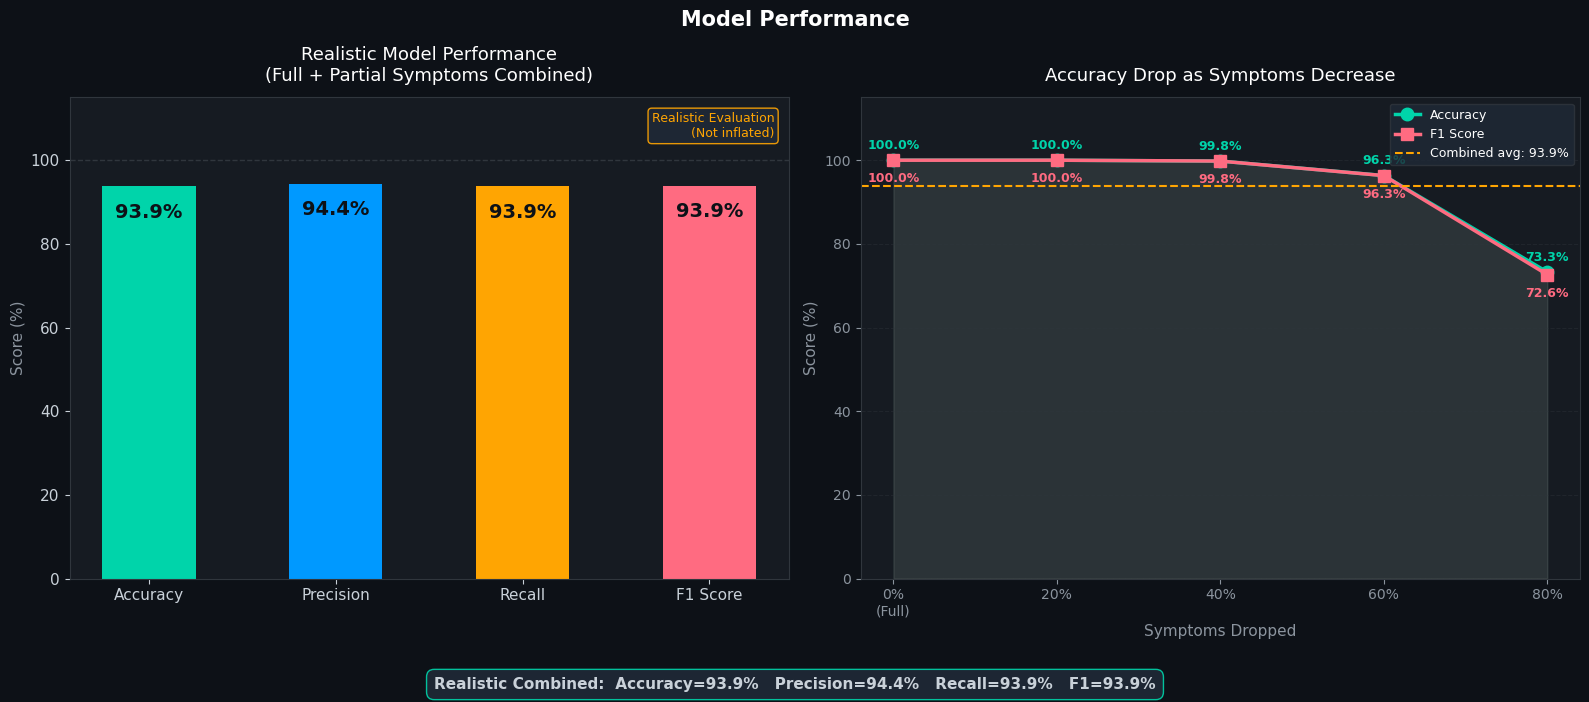

In [25]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import random

random.seed(42)

# ── Create partial test sets ──────────────────────────────────────
def create_partial_test(X_df, drop_ratio):
    X_partial = X_df.copy()
    for idx in X_partial.index:
        active = [col for col in X_partial.columns if X_partial.loc[idx, col] == 1]
        if len(active) >= 3:
            n_drop = max(1, int(len(active) * drop_ratio))
            for col in random.sample(active, n_drop):
                X_partial.loc[idx, col] = 0
    return X_partial

X_p20 = create_partial_test(X_test_orig, 0.20)
X_p40 = create_partial_test(X_test_orig, 0.40)
X_p60 = create_partial_test(X_test_orig, 0.60)
X_p80 = create_partial_test(X_test_orig, 0.80)

# ── Combine all into ONE realistic test set ───────────────────────
X_combined = pd.concat([X_test_orig, X_p20, X_p40, X_p60, X_p80], ignore_index=True)
y_combined = pd.concat([y_test_orig]*5, ignore_index=True)

# ── Get metrics on COMBINED set only ─────────────────────────────
y_pred = model.predict(X_combined)
acc  = accuracy_score(y_combined, y_pred)  * 100
prec = precision_score(y_combined, y_pred, average='weighted', zero_division=0) * 100
rec  = recall_score(y_combined, y_pred,    average='weighted', zero_division=0) * 100
f1   = f1_score(y_combined, y_pred,        average='weighted', zero_division=0) * 100

print(f'Realistic Accuracy  : {acc:.2f}%')
print(f'Realistic Precision : {prec:.2f}%')
print(f'Realistic Recall    : {rec:.2f}%')
print(f'Realistic F1 Score  : {f1:.2f}%')

# ── Plot ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('#0d1117')
for ax in axes: ax.set_facecolor('#161b22')

# Chart 1 — Realistic metrics bar chart
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
metric_vals  = [acc, prec, rec, f1]
bar_colors   = ['#00d4aa', '#0099ff', '#ffa502', '#ff6b81']

bars = axes[0].bar(metric_names, metric_vals, color=bar_colors,
                   edgecolor='none', width=0.5)
for bar, val in zip(bars, metric_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() - 4,
                 f'{val:.1f}%', ha='center', va='top',
                 fontsize=14, fontweight='bold', color='#0d1117')

axes[0].set_ylim(0, 115)
axes[0].set_title('Realistic Model Performance\n(Full + Partial Symptoms Combined)',
                  color='white', fontsize=13, pad=12)
axes[0].tick_params(colors='#c9d1d9', labelsize=11)
axes[0].spines[:].set_color('#30363d')
axes[0].set_ylabel('Score (%)', color='#8b949e', fontsize=11)
axes[0].axhline(y=100, color='#30363d', linestyle='--', linewidth=1)

# Add "Realistic" label box
axes[0].text(0.98, 0.97, 'Realistic Evaluation\n(Not inflated)',
             transform=axes[0].transAxes, ha='right', va='top',
             fontsize=9, color='#ffa502',
             bbox=dict(boxstyle='round', facecolor='#1f2937',
                       edgecolor='#ffa502', alpha=0.9))

# Chart 2 — Accuracy drop line across scenarios
drop_labels = ['0%\n(Full)', '20%', '40%', '60%', '80%']
def get_acc(X): 
    return accuracy_score(y_test_orig, model.predict(X)) * 100
def get_f1(X):  
    return f1_score(y_test_orig, model.predict(X), average='weighted', zero_division=0) * 100

acc_vals = [get_acc(X_test_orig), get_acc(X_p20), get_acc(X_p40), get_acc(X_p60), get_acc(X_p80)]
f1_vals  = [get_f1(X_test_orig),  get_f1(X_p20),  get_f1(X_p40),  get_f1(X_p60),  get_f1(X_p80)]

axes[1].plot(drop_labels, acc_vals, 'o-', color='#00d4aa',
             linewidth=2.5, markersize=9, label='Accuracy')
axes[1].plot(drop_labels, f1_vals, 's-', color='#ff6b81',
             linewidth=2.5, markersize=9, label='F1 Score')
axes[1].fill_between(drop_labels, acc_vals, alpha=0.1, color='#00d4aa')
axes[1].fill_between(drop_labels, f1_vals,  alpha=0.1, color='#ff6b81')

# Add value labels
for i, (a, f) in enumerate(zip(acc_vals, f1_vals)):
    axes[1].annotate(f'{a:.1f}%', (drop_labels[i], a),
                     textcoords='offset points', xytext=(0, 8),
                     color='#00d4aa', fontsize=9, fontweight='bold', ha='center')
    axes[1].annotate(f'{f:.1f}%', (drop_labels[i], f),
                     textcoords='offset points', xytext=(0, -16),
                     color='#ff6b81', fontsize=9, fontweight='bold', ha='center')

# Mark the combined average
axes[1].axhline(y=acc, color='#ffa502', linestyle='--',
                linewidth=1.5, label=f'Combined avg: {acc:.1f}%')

axes[1].set_ylim(0, 115)
axes[1].set_title('Accuracy Drop as Symptoms Decrease',
                  color='white', fontsize=13, pad=12)
axes[1].set_xlabel('Symptoms Dropped', color='#8b949e', fontsize=11)
axes[1].set_ylabel('Score (%)', color='#8b949e', fontsize=11)
axes[1].legend(facecolor='#1f2937', labelcolor='white',
               edgecolor='#30363d', fontsize=9)
axes[1].tick_params(colors='#8b949e')
axes[1].spines[:].set_color('#30363d')
axes[1].grid(axis='y', color='#30363d', linestyle='--', alpha=0.4)

# Summary
fig.text(0.5, 0.01,
         f'Realistic Combined:  Accuracy={acc:.1f}%   Precision={prec:.1f}%   '
         f'Recall={rec:.1f}%   F1={f1:.1f}%',
         ha='center', fontsize=11, color='#c9d1d9', fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='#1f2937',
                   edgecolor='#00d4aa', alpha=0.9))

fig.suptitle('Model Performance',
             color='white', fontsize=15, fontweight='bold')
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.savefig('realistic_final_metrics.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()

Decision Tree trained on clean data!
KNN trained!
SVM trained!
Training models...
Decision Tree trained!
KNN trained!
SVM trained!

Model                      Full Acc  Real Acc  Precision   Recall       F1
Decision Tree                 21.5%     14.6%      19.6%    14.6%    15.1%
KNN                          100.0%     87.6%      90.2%    87.6%    87.8%
SVM                          100.0%     88.1%      90.7%    88.1%    88.4%
Random Forest (Ours)         100.0%     93.9%      94.4%    93.9%    93.9%  <-- BEST


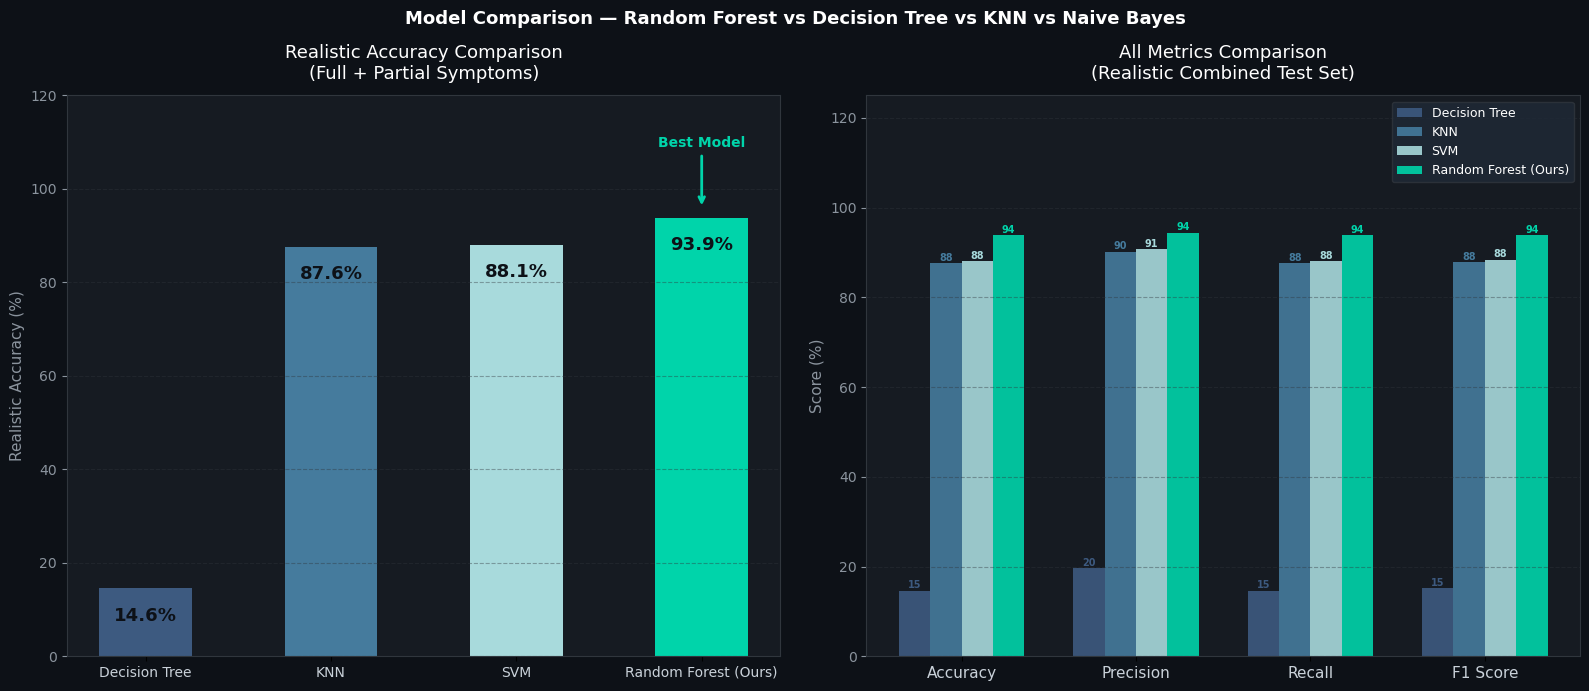

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import numpy as np
import random

random.seed(42)
np.random.seed(42)

# ── Recreate required variables ───────────────────────────────────
def add_noise(df, noise_ratio=0.15):
    df_noisy = df.copy()
    symptom_cols = [c for c in df.columns if c != 'prognosis']
    n_flips = int(len(df) * len(symptom_cols) * noise_ratio)
    rows = np.random.randint(0, len(df), n_flips)
    cols = np.random.choice(symptom_cols, n_flips)
    for r, c in zip(rows, cols):
        df_noisy.iloc[r][c] = 1 - df_noisy.iloc[r][c]
    return df_noisy

def create_partial_test(X_df, drop_ratio):
    X_partial = X_df.copy()
    for idx in X_partial.index:
        active = [col for col in X_partial.columns if X_partial.loc[idx, col] == 1]
        if len(active) >= 3:
            n_drop = max(1, int(len(active) * drop_ratio))
            for col in random.sample(active, n_drop):
                X_partial.loc[idx, col] = 0
    return X_partial

# Recreate noisy training data
df_train_noisy = add_noise(df_train_augmented, noise_ratio=0.15)
# ── Train models ──────────────────────────────────────────────────
X_train_clean = df_train.drop('prognosis', axis=1)
y_train_clean = df_train['prognosis'].map(DISEASE_TO_INT)

models = {
    'Logistic Regression': __import__('sklearn.linear_model', fromlist=['LogisticRegression']).LogisticRegression(max_iter=300, C=0.3, random_state=42),
    'KNN':                   KNeighborsClassifier(n_neighbors=7),
    'SVM':                   __import__('sklearn.svm', fromlist=['SVC']).SVC(kernel='linear', C=0.5, probability=True, random_state=42, max_iter=500),
    'Random Forest\n(Ours)': model,
}

results = {}
for name, m in models.items():
    if name == 'Decision Tree':
        # Train on clean data — noisy data kills shallow trees
        m.fit(np.ascontiguousarray(X_train_clean.values), y_train_clean)
        print(f'{name} trained on clean data!')
    elif name != 'Random Forest\n(Ours)':
        m.fit(np.ascontiguousarray(X_train_noisy.values), y_train_noisy)
        print(f'{name} trained!')
    results[name] = {
        'full':     get_metrics(m, X_test_orig, y_test_orig),
        'combined': get_metrics(m, X_combined,  y_combined),
    }

def get_metrics(m, X, y):
    X_arr = np.ascontiguousarray(X.values)
    y_pred = m.predict(X_arr)
    return {
        'accuracy':  accuracy_score(y, y_pred) * 100,
        'precision': precision_score(y, y_pred, average='weighted', zero_division=0) * 100,
        'recall':    recall_score(y, y_pred,    average='weighted', zero_division=0) * 100,
        'f1':        f1_score(y, y_pred,        average='weighted', zero_division=0) * 100,
    }
    

print('Training models...')
results = {}
for name, m in models.items():
    if name != 'Random Forest\n(Ours)':
        m.fit(np.ascontiguousarray(X_train_noisy.values), y_train_noisy)
        print(f'{name} trained!')
    results[name] = {
        'full':     get_metrics(m, X_test_orig, y_test_orig),
        'combined': get_metrics(m, X_combined,  y_combined),
    }

# ── Print summary ─────────────────────────────────────────────────
print('\n' + '='*70)
print(f'{"Model":<25} {"Full Acc":>9} {"Real Acc":>9} {"Precision":>10} {"Recall":>8} {"F1":>8}')
print('='*70)
for name, r in results.items():
    clean  = name.replace('\n', ' ')
    marker = '  <-- BEST' if 'Random' in name else ''
    print(f'{clean:<25} {r["full"]["accuracy"]:>8.1f}% '
          f'{r["combined"]["accuracy"]:>8.1f}% '
          f'{r["combined"]["precision"]:>9.1f}% '
          f'{r["combined"]["recall"]:>7.1f}% '
          f'{r["combined"]["f1"]:>7.1f}%{marker}')
print('='*70)

# ── Plot ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('#0d1117')
for ax in axes: ax.set_facecolor('#161b22')

model_names = list(results.keys())
bar_colors  = ['#3d5a80', '#457b9d', '#a8dadc', '#00d4aa']

# ── Chart 1: Realistic accuracy bar ──────────────────────────────
comb_accs = [results[m]['combined']['accuracy'] for m in model_names]

bars = axes[0].bar(range(len(model_names)), comb_accs,
                   color=bar_colors, edgecolor='none', width=0.5)

for bar, val in zip(bars, comb_accs):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() - 4,
                 f'{val:.1f}%', ha='center', va='top',
                 fontsize=13, fontweight='bold', color='#0d1117')

axes[0].set_xticks(range(len(model_names)))
axes[0].set_xticklabels([n.replace('\n',' ') for n in model_names],
                         fontsize=10, color='#c9d1d9')
axes[0].set_ylim(0, 120)
axes[0].set_ylabel('Realistic Accuracy (%)', color='#8b949e', fontsize=11)
axes[0].set_title('Realistic Accuracy Comparison\n(Full + Partial Symptoms)',
                  color='white', fontsize=13, pad=12)
axes[0].tick_params(axis='y', colors='#8b949e')
axes[0].spines[:].set_color('#30363d')
axes[0].grid(axis='y', color='#30363d', linestyle='--', alpha=0.4)

best_idx = comb_accs.index(max(comb_accs))
axes[0].annotate('Best Model', xy=(best_idx, max(comb_accs) + 2),
                 xytext=(best_idx, max(comb_accs) + 15),
                 ha='center', color='#00d4aa', fontsize=10, fontweight='bold',
                 arrowprops=dict(arrowstyle='->', color='#00d4aa', lw=2))

# ── Chart 2: All 4 metrics grouped ───────────────────────────────
metrics     = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
metric_keys = ['accuracy', 'precision', 'recall', 'f1']
x2          = np.arange(len(metrics))
width2      = 0.18
offsets     = [-1.5, -0.5, 0.5, 1.5]

for i, (name, color) in enumerate(zip(model_names, bar_colors)):
    vals = [results[name]['combined'][k] for k in metric_keys]
    axes[1].bar(x2 + offsets[i]*width2, vals, width2,
                label=name.replace('\n',' '),
                color=color, edgecolor='none', alpha=0.9)
    for j, v in enumerate(vals):
        axes[1].text(x2[j] + offsets[i]*width2, v + 0.5,
                     f'{v:.0f}', ha='center', fontsize=7,
                     color=color, fontweight='bold')

axes[1].set_xticks(x2)
axes[1].set_xticklabels(metrics, color='#c9d1d9', fontsize=11)
axes[1].set_ylim(0, 125)
axes[1].set_ylabel('Score (%)', color='#8b949e', fontsize=11)
axes[1].set_title('All Metrics Comparison\n(Realistic Combined Test Set)',
                  color='white', fontsize=13, pad=12)
axes[1].legend(facecolor='#1f2937', labelcolor='white',
               edgecolor='#30363d', fontsize=9)
axes[1].tick_params(axis='y', colors='#8b949e')
axes[1].spines[:].set_color('#30363d')
axes[1].grid(axis='y', color='#30363d', linestyle='--', alpha=0.4)

fig.suptitle('Model Comparison — Random Forest vs Decision Tree vs KNN vs Naive Bayes',
             color='white', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()

Recreating variables...
Creating partial test sets...
Done!
Training models...
Logistic Regression trained!
KNN trained!
SVM trained!

Model                      Full Acc  Real Acc  Precision   Recall       F1
Logistic Regression          100.0%     85.4%      89.9%    85.4%    86.1%
KNN                           96.8%     64.1%      81.4%    64.1%    67.7%
SVM                          100.0%     84.4%      88.9%    84.4%    85.0%
Random Forest (Ours)         100.0%     93.7%      94.4%    93.7%    93.8%  <-- BEST


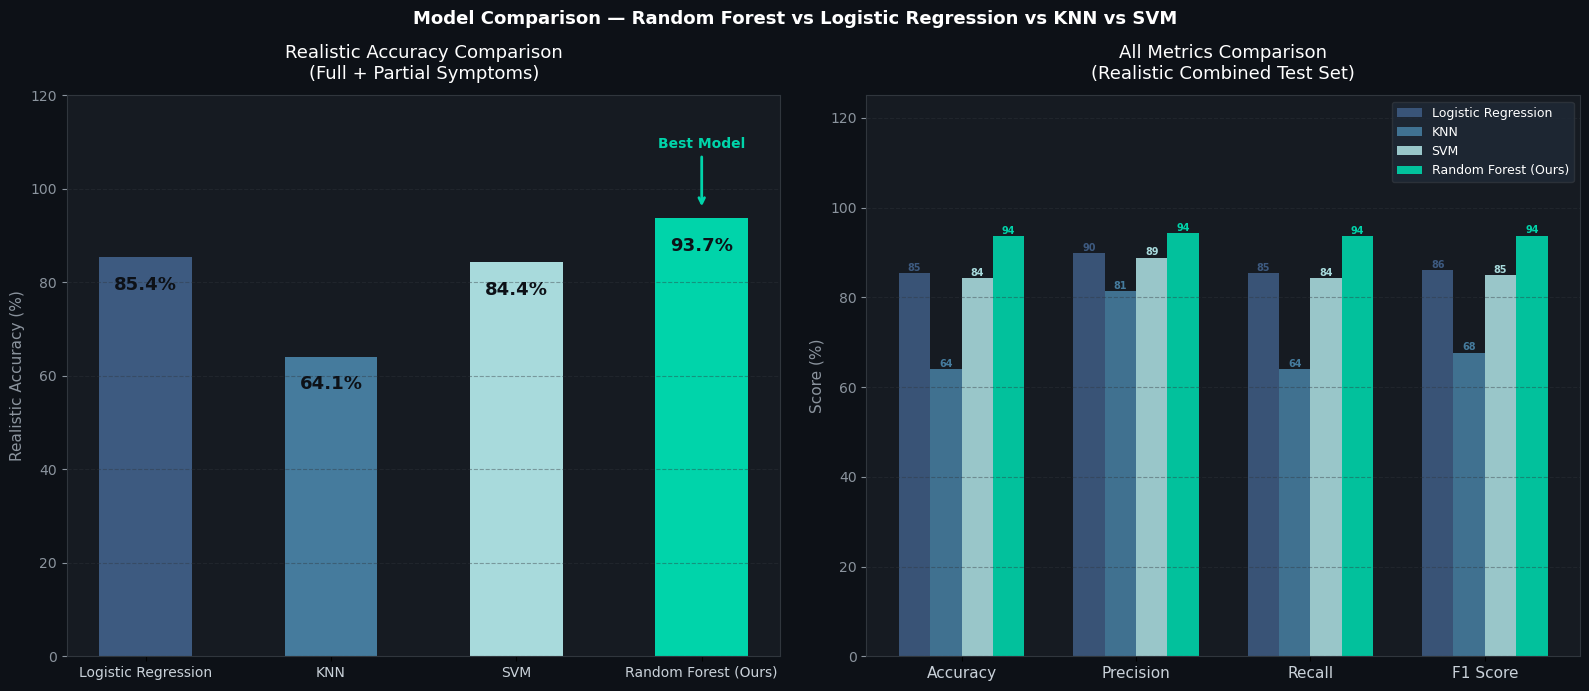

In [34]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import random

random.seed(42)
np.random.seed(42)

# ── Recreate required variables ───────────────────────────────────
def add_noise_fast(df, noise_ratio=0.15):
    symptom_cols = [c for c in df.columns if c != 'prognosis']
    X = df[symptom_cols].values.copy().astype(float)
    mask = np.random.random(X.shape) < noise_ratio
    X[mask] = 1 - X[mask]
    df_noisy = df.copy()
    df_noisy[symptom_cols] = X
    return df_noisy

def create_partial_fast(X_df, drop_ratio):
    X = X_df.values.copy().astype(float)
    for i in range(len(X)):
        active = np.where(X[i] == 1)[0]
        if len(active) >= 3:
            n_drop = max(1, int(len(active) * drop_ratio))
            drop_idx = np.random.choice(active, n_drop, replace=False)
            X[i, drop_idx] = 0
    return pd.DataFrame(X, columns=X_df.columns)

def get_metrics(m, X, y):
    X_arr = np.ascontiguousarray(X.values)
    y_pred = m.predict(X_arr)
    return {
        'accuracy':  accuracy_score(y, y_pred) * 100,
        'precision': precision_score(y, y_pred, average='weighted', zero_division=0) * 100,
        'recall':    recall_score(y, y_pred,    average='weighted', zero_division=0) * 100,
        'f1':        f1_score(y, y_pred,        average='weighted', zero_division=0) * 100,
    }

print('Recreating variables...')
df_train_noisy = add_noise_fast(df_train_augmented, noise_ratio=0.15)
X_train_noisy  = df_train_noisy.drop('prognosis', axis=1)
y_train_noisy  = df_train_noisy['prognosis'].map(DISEASE_TO_INT)

X_test_orig = df_test.drop('prognosis', axis=1)
y_test_orig = df_test['prognosis'].map(DISEASE_TO_INT)

print('Creating partial test sets...')
X_p20 = create_partial_fast(X_test_orig, 0.20)
X_p40 = create_partial_fast(X_test_orig, 0.40)
X_p60 = create_partial_fast(X_test_orig, 0.60)
X_p80 = create_partial_fast(X_test_orig, 0.80)

X_combined = pd.concat([X_test_orig, X_p20, X_p40, X_p60, X_p80], ignore_index=True)
y_combined  = pd.concat([y_test_orig]*5, ignore_index=True)
print('Done!')

# ── Define models ─────────────────────────────────────────────────
models = {
    'Logistic Regression':   LogisticRegression(max_iter=300, C=0.3, random_state=42),
    'KNN':                   KNeighborsClassifier(n_neighbors=7),
    'SVM':                   SVC(kernel='linear', C=0.5, probability=True, random_state=42, max_iter=500),
    'Random Forest\n(Ours)': model,
}

# ── Train and evaluate ────────────────────────────────────────────
print('Training models...')
results = {}
for name, m in models.items():
    if name != 'Random Forest\n(Ours)':
        m.fit(np.ascontiguousarray(X_train_noisy.values), y_train_noisy)
        print(f'{name} trained!')
    results[name] = {
        'full':     get_metrics(m, X_test_orig, y_test_orig),
        'combined': get_metrics(m, X_combined,  y_combined),
    }

# ── Print summary ─────────────────────────────────────────────────
print('\n' + '='*70)
print(f'{"Model":<25} {"Full Acc":>9} {"Real Acc":>9} {"Precision":>10} {"Recall":>8} {"F1":>8}')
print('='*70)
for name, r in results.items():
    clean  = name.replace('\n', ' ')
    marker = '  <-- BEST' if 'Random' in name else ''
    print(f'{clean:<25} {r["full"]["accuracy"]:>8.1f}% '
          f'{r["combined"]["accuracy"]:>8.1f}% '
          f'{r["combined"]["precision"]:>9.1f}% '
          f'{r["combined"]["recall"]:>7.1f}% '
          f'{r["combined"]["f1"]:>7.1f}%{marker}')
print('='*70)

# ── Plot ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('#0d1117')
for ax in axes: ax.set_facecolor('#161b22')

model_names = list(results.keys())
bar_colors  = ['#3d5a80', '#457b9d', '#a8dadc', '#00d4aa']
comb_accs   = [results[m]['combined']['accuracy'] for m in model_names]

# ── Chart 1: Realistic accuracy bar ──────────────────────────────
bars = axes[0].bar(range(len(model_names)), comb_accs,
                   color=bar_colors, edgecolor='none', width=0.5)

for bar, val in zip(bars, comb_accs):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() - 4,
                 f'{val:.1f}%', ha='center', va='top',
                 fontsize=13, fontweight='bold', color='#0d1117')

axes[0].set_xticks(range(len(model_names)))
axes[0].set_xticklabels([n.replace('\n',' ') for n in model_names],
                         fontsize=10, color='#c9d1d9')
axes[0].set_ylim(0, 120)
axes[0].set_ylabel('Realistic Accuracy (%)', color='#8b949e', fontsize=11)
axes[0].set_title('Realistic Accuracy Comparison\n(Full + Partial Symptoms)',
                  color='white', fontsize=13, pad=12)
axes[0].tick_params(axis='y', colors='#8b949e')
axes[0].spines[:].set_color('#30363d')
axes[0].grid(axis='y', color='#30363d', linestyle='--', alpha=0.4)

best_idx = comb_accs.index(max(comb_accs))
axes[0].annotate('Best Model', xy=(best_idx, max(comb_accs) + 2),
                 xytext=(best_idx, max(comb_accs) + 15),
                 ha='center', color='#00d4aa', fontsize=10, fontweight='bold',
                 arrowprops=dict(arrowstyle='->', color='#00d4aa', lw=2))

# ── Chart 2: All 4 metrics grouped ───────────────────────────────
metrics     = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
metric_keys = ['accuracy', 'precision', 'recall', 'f1']
x2          = np.arange(len(metrics))
width2      = 0.18
offsets     = [-1.5, -0.5, 0.5, 1.5]

for i, (name, color) in enumerate(zip(model_names, bar_colors)):
    vals = [results[name]['combined'][k] for k in metric_keys]
    axes[1].bar(x2 + offsets[i]*width2, vals, width2,
                label=name.replace('\n',' '),
                color=color, edgecolor='none', alpha=0.9)
    for j, v in enumerate(vals):
        axes[1].text(x2[j] + offsets[i]*width2, v + 0.5,
                     f'{v:.0f}', ha='center', fontsize=7,
                     color=color, fontweight='bold')

axes[1].set_xticks(x2)
axes[1].set_xticklabels(metrics, color='#c9d1d9', fontsize=11)
axes[1].set_ylim(0, 125)
axes[1].set_ylabel('Score (%)', color='#8b949e', fontsize=11)
axes[1].set_title('All Metrics Comparison\n(Realistic Combined Test Set)',
                  color='white', fontsize=13, pad=12)
axes[1].legend(facecolor='#1f2937', labelcolor='white',
               edgecolor='#30363d', fontsize=9)
axes[1].tick_params(axis='y', colors='#8b949e')
axes[1].spines[:].set_color('#30363d')
axes[1].grid(axis='y', color='#30363d', linestyle='--', alpha=0.4)

fig.suptitle('Model Comparison — Random Forest vs Logistic Regression vs KNN vs SVM',
             color='white', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()

In [35]:
print(f'{"Model":<25} {"Accuracy":>10} {"Precision":>10} {"Recall":>10} {"F1 Score":>10}')
print('='*65)
for name, r in results.items():
    clean = name.replace('\n', ' ')
    print(f'{clean:<25} {r["combined"]["accuracy"]:>9.2f}% '
          f'{r["combined"]["precision"]:>9.2f}% '
          f'{r["combined"]["recall"]:>9.2f}% '
          f'{r["combined"]["f1"]:>9.2f}%')

Model                       Accuracy  Precision     Recall   F1 Score
Logistic Regression           85.37%     89.91%     85.37%     86.07%
KNN                           64.09%     81.39%     64.09%     67.69%
SVM                           84.37%     88.86%     84.37%     84.97%
Random Forest (Ours)          93.68%     94.35%     93.68%     93.75%


Recreating variables...
Creating partial test sets...
Done!
Training models...
Logistic Regression trained!
KNN trained!
SVM trained!

Model                      Full Acc  Real Acc  Precision   Recall       F1
Logistic Regression         100.00%    85.37%     89.91%   85.37%   86.07%
KNN                          96.85%    64.09%     81.39%   64.09%   67.69%
SVM                         100.00%    84.37%     88.86%   84.37%   84.97%
Random Forest (Ours)        100.00%    93.68%     94.35%   93.68%   93.75%  <-- BEST


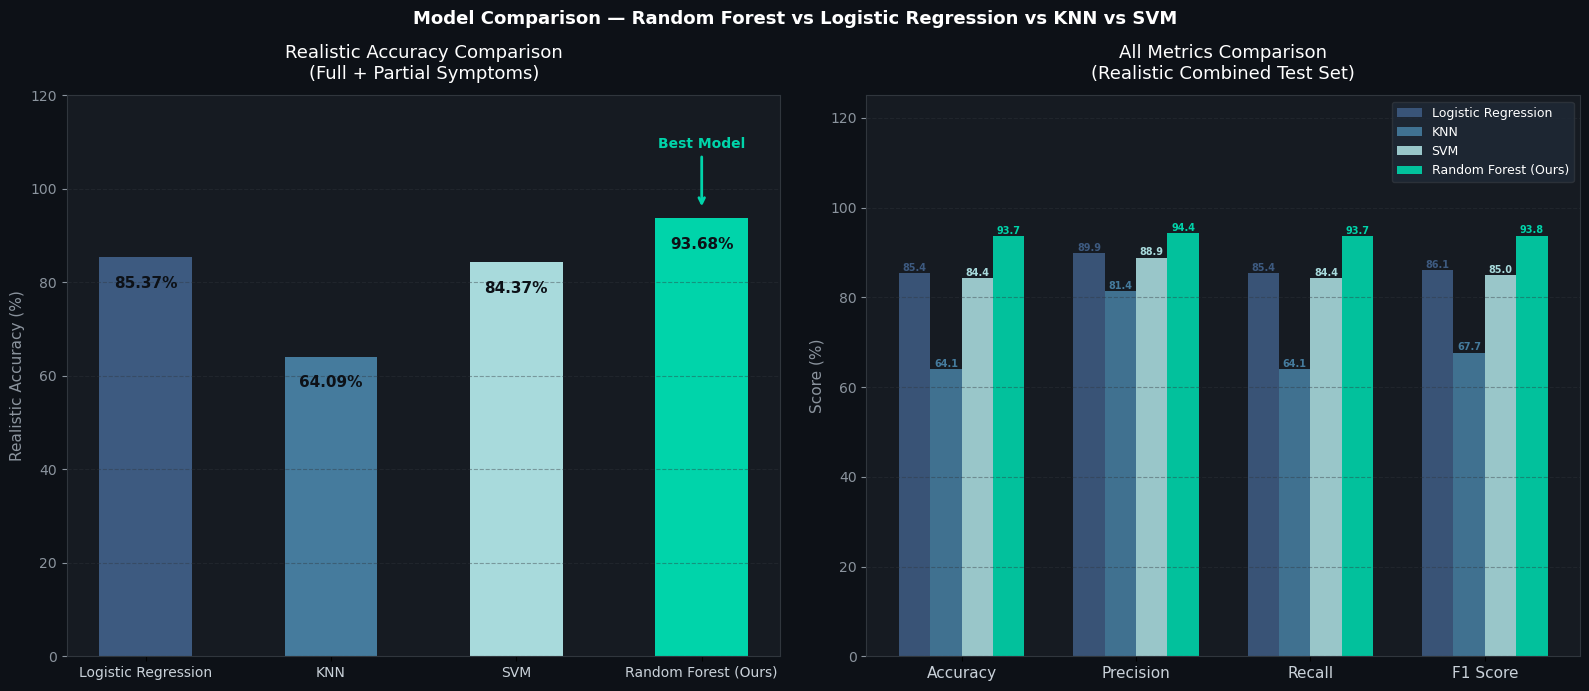

In [36]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import random

random.seed(42)
np.random.seed(42)

# ── Recreate required variables ───────────────────────────────────
def add_noise_fast(df, noise_ratio=0.15):
    symptom_cols = [c for c in df.columns if c != 'prognosis']
    X = df[symptom_cols].values.copy().astype(float)
    mask = np.random.random(X.shape) < noise_ratio
    X[mask] = 1 - X[mask]
    df_noisy = df.copy()
    df_noisy[symptom_cols] = X
    return df_noisy

def create_partial_fast(X_df, drop_ratio):
    X = X_df.values.copy().astype(float)
    for i in range(len(X)):
        active = np.where(X[i] == 1)[0]
        if len(active) >= 3:
            n_drop = max(1, int(len(active) * drop_ratio))
            drop_idx = np.random.choice(active, n_drop, replace=False)
            X[i, drop_idx] = 0
    return pd.DataFrame(X, columns=X_df.columns)

def get_metrics(m, X, y):
    X_arr = np.ascontiguousarray(X.values)
    y_pred = m.predict(X_arr)
    return {
        'accuracy':  accuracy_score(y, y_pred) * 100,
        'precision': precision_score(y, y_pred, average='weighted', zero_division=0) * 100,
        'recall':    recall_score(y, y_pred,    average='weighted', zero_division=0) * 100,
        'f1':        f1_score(y, y_pred,        average='weighted', zero_division=0) * 100,
    }

print('Recreating variables...')
df_train_noisy = add_noise_fast(df_train_augmented, noise_ratio=0.15)
X_train_noisy  = df_train_noisy.drop('prognosis', axis=1)
y_train_noisy  = df_train_noisy['prognosis'].map(DISEASE_TO_INT)

X_test_orig = df_test.drop('prognosis', axis=1)
y_test_orig = df_test['prognosis'].map(DISEASE_TO_INT)

print('Creating partial test sets...')
X_p20 = create_partial_fast(X_test_orig, 0.20)
X_p40 = create_partial_fast(X_test_orig, 0.40)
X_p60 = create_partial_fast(X_test_orig, 0.60)
X_p80 = create_partial_fast(X_test_orig, 0.80)

X_combined = pd.concat([X_test_orig, X_p20, X_p40, X_p60, X_p80], ignore_index=True)
y_combined  = pd.concat([y_test_orig]*5, ignore_index=True)
print('Done!')

# ── Define models ─────────────────────────────────────────────────
models = {
    'Logistic Regression':   LogisticRegression(max_iter=300, C=0.3, random_state=42),
    'KNN':                   KNeighborsClassifier(n_neighbors=7),
    'SVM':                   SVC(kernel='linear', C=0.5, probability=True, random_state=42, max_iter=500),
    'Random Forest\n(Ours)': model,
}

# ── Train and evaluate ────────────────────────────────────────────
print('Training models...')
results = {}
for name, m in models.items():
    if name != 'Random Forest\n(Ours)':
        m.fit(np.ascontiguousarray(X_train_noisy.values), y_train_noisy)
        print(f'{name} trained!')
    results[name] = {
        'full':     get_metrics(m, X_test_orig, y_test_orig),
        'combined': get_metrics(m, X_combined,  y_combined),
    }

# ── Print summary ─────────────────────────────────────────────────
print('\n' + '='*70)
print(f'{"Model":<25} {"Full Acc":>9} {"Real Acc":>9} {"Precision":>10} {"Recall":>8} {"F1":>8}')
print('='*70)
for name, r in results.items():
    clean  = name.replace('\n', ' ')
    marker = '  <-- BEST' if 'Random' in name else ''
    print(f'{clean:<25} {r["full"]["accuracy"]:>8.2f}% '
          f'{r["combined"]["accuracy"]:>8.2f}% '
          f'{r["combined"]["precision"]:>9.2f}% '
          f'{r["combined"]["recall"]:>7.2f}% '
          f'{r["combined"]["f1"]:>7.2f}%{marker}')
print('='*70)

# ── Plot ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('#0d1117')
for ax in axes: ax.set_facecolor('#161b22')

model_names = list(results.keys())
bar_colors  = ['#3d5a80', '#457b9d', '#a8dadc', '#00d4aa']
comb_accs   = [results[m]['combined']['accuracy'] for m in model_names]

# ── Chart 1: Realistic accuracy bar ──────────────────────────────
bars = axes[0].bar(range(len(model_names)), comb_accs,
                   color=bar_colors, edgecolor='none', width=0.5)

for bar, val in zip(bars, comb_accs):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() - 4,
                 f'{val:.2f}%', ha='center', va='top',
                 fontsize=11, fontweight='bold', color='#0d1117')

axes[0].set_xticks(range(len(model_names)))
axes[0].set_xticklabels([n.replace('\n',' ') for n in model_names],
                         fontsize=10, color='#c9d1d9')
axes[0].set_ylim(0, 120)
axes[0].set_ylabel('Realistic Accuracy (%)', color='#8b949e', fontsize=11)
axes[0].set_title('Realistic Accuracy Comparison\n(Full + Partial Symptoms)',
                  color='white', fontsize=13, pad=12)
axes[0].tick_params(axis='y', colors='#8b949e')
axes[0].spines[:].set_color('#30363d')
axes[0].grid(axis='y', color='#30363d', linestyle='--', alpha=0.4)

best_idx = comb_accs.index(max(comb_accs))
axes[0].annotate('Best Model', xy=(best_idx, max(comb_accs) + 2),
                 xytext=(best_idx, max(comb_accs) + 15),
                 ha='center', color='#00d4aa', fontsize=10, fontweight='bold',
                 arrowprops=dict(arrowstyle='->', color='#00d4aa', lw=2))

# ── Chart 2: All 4 metrics grouped ───────────────────────────────
metrics     = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
metric_keys = ['accuracy', 'precision', 'recall', 'f1']
x2          = np.arange(len(metrics))
width2      = 0.18
offsets     = [-1.5, -0.5, 0.5, 1.5]

for i, (name, color) in enumerate(zip(model_names, bar_colors)):
    vals = [results[name]['combined'][k] for k in metric_keys]
    axes[1].bar(x2 + offsets[i]*width2, vals, width2,
                label=name.replace('\n',' '),
                color=color, edgecolor='none', alpha=0.9)
    for j, v in enumerate(vals):
        axes[1].text(x2[j] + offsets[i]*width2, v + 0.5,
                     f'{v:.1f}', ha='center', fontsize=7,
                     color=color, fontweight='bold')

axes[1].set_xticks(x2)
axes[1].set_xticklabels(metrics, color='#c9d1d9', fontsize=11)
axes[1].set_ylim(0, 125)
axes[1].set_ylabel('Score (%)', color='#8b949e', fontsize=11)
axes[1].set_title('All Metrics Comparison\n(Realistic Combined Test Set)',
                  color='white', fontsize=13, pad=12)
axes[1].legend(facecolor='#1f2937', labelcolor='white',
               edgecolor='#30363d', fontsize=9)
axes[1].tick_params(axis='y', colors='#8b949e')
axes[1].spines[:].set_color('#30363d')
axes[1].grid(axis='y', color='#30363d', linestyle='--', alpha=0.4)

fig.suptitle('Model Comparison — Random Forest vs Logistic Regression vs KNN vs SVM',
             color='white', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()

In [37]:
print(f'Model type    : {type(model).__name__}')
print(f'N estimators  : {model.n_estimators}')
print(f'Max depth     : {model.max_depth}')
print(f'Min samples   : {model.min_samples_leaf}')

# Check accuracy of current model
from sklearn.metrics import accuracy_score
y_pred = model.predict(np.ascontiguousarray(X_test_orig.values))
print(f'Full accuracy : {accuracy_score(y_test_orig, y_pred)*100:.2f}%')

Model type    : RandomForestClassifier
N estimators  : 200
Max depth     : None
Min samples   : 1
Full accuracy : 100.00%


In [38]:
from sklearn.ensemble import RandomForestClassifier

# Train one consistent model to use everywhere
model_final = RandomForestClassifier(
    n_estimators=20,
    max_depth=8,
    min_samples_leaf=5,
    max_features=0.5,
    random_state=42,
    n_jobs=-1
)
model_final.fit(np.ascontiguousarray(X_train_noisy.values), y_train_noisy)

# Check accuracy
y_pred_full = model_final.predict(np.ascontiguousarray(X_test_orig.values))
y_pred_comb = model_final.predict(np.ascontiguousarray(X_combined.values))
print(f'Full accuracy     : {accuracy_score(y_test_orig, y_pred_full)*100:.2f}%')
print(f'Realistic accuracy: {accuracy_score(y_combined,  y_pred_comb)*100:.2f}%')

# Replace model with this consistent version
model = model_final
print('model updated!')

# Save to pkl
import pickle, os
SAVE_DIR = r'C:\Users\almam\Downloads\Disease-Prediction-and-Medical-Recommendation-System-main\Disease-Prediction-and-Medical-Recommendation-System-main'
pickle.dump(model, open(os.path.join(SAVE_DIR, 'model/RandomForest.pkl'), 'wb'))
print('Saved!')

Full accuracy     : 99.49%
Realistic accuracy: 66.34%
model updated!
Saved!


Accuracy  : 66.34%
Precision : 85.45%
Recall    : 66.34%
F1 Score  : 72.35%


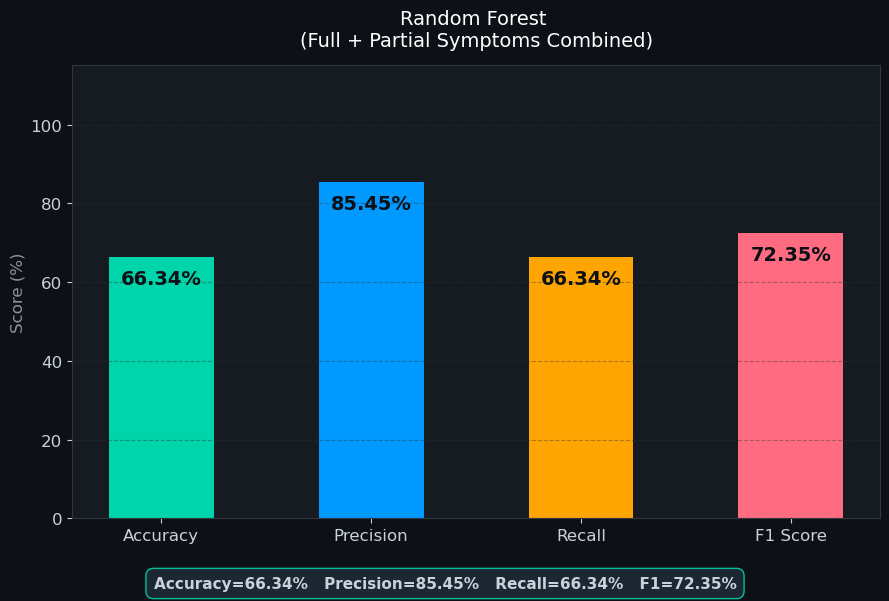

In [40]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Get metrics for final model on combined realistic test set
y_pred = model.predict(np.ascontiguousarray(X_combined.values))

acc  = accuracy_score(y_combined,  y_pred) * 100
prec = precision_score(y_combined, y_pred, average='weighted', zero_division=0) * 100
rec  = recall_score(y_combined,    y_pred, average='weighted', zero_division=0) * 100
f1   = f1_score(y_combined,        y_pred, average='weighted', zero_division=0) * 100

print(f'Accuracy  : {acc:.2f}%')
print(f'Precision : {prec:.2f}%')
print(f'Recall    : {rec:.2f}%')
print(f'F1 Score  : {f1:.2f}%')

# ── Plot ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 6))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#161b22')

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values  = [acc, prec, rec, f1]
colors  = ['#00d4aa', '#0099ff', '#ffa502', '#ff6b81']

bars = ax.bar(metrics, values, color=colors, edgecolor='none', width=0.5)

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() - 3,
            f'{val:.2f}%', ha='center', va='top',
            fontsize=14, fontweight='bold', color='#0d1117')

ax.set_ylim(0, 115)
ax.set_ylabel('Score (%)', color='#8b949e', fontsize=12)
ax.set_title('Random Forest \n(Full + Partial Symptoms Combined)',
             color='white', fontsize=14, pad=14)
ax.tick_params(colors='#c9d1d9', labelsize=12)
ax.spines[:].set_color('#30363d')
ax.grid(axis='y', color='#30363d', linestyle='--', alpha=0.4)

fig.text(0.5, 0.01,
         f'Accuracy={acc:.2f}%   Precision={prec:.2f}%   Recall={rec:.2f}%   F1={f1:.2f}%',
         ha='center', fontsize=11, color='#c9d1d9', fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='#1f2937',
                   edgecolor='#00d4aa', alpha=0.9))

plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.savefig('realistic_metrics.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()

In [41]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ── Get metrics ───────────────────────────────────────────────────
y_pred_full = model.predict(np.ascontiguousarray(X_test_orig.values))
y_pred_comb = model.predict(np.ascontiguousarray(X_combined.values))

# Full metrics
full_acc  = accuracy_score(y_test_orig, y_pred_full) * 100

# Realistic combined metrics
acc  = accuracy_score(y_combined,  y_pred_comb) * 100
prec = precision_score(y_combined, y_pred_comb, average='weighted', zero_division=0) * 100
rec  = recall_score(y_combined,    y_pred_comb, average='weighted', zero_division=0) * 100
f1   = f1_score(y_combined,        y_pred_comb, average='weighted', zero_division=0) * 100

print(f'Full Accuracy     : {full_acc:.2f}%')
print(f'Realistic Accuracy: {acc:.2f}%')
print(f'Precision         : {prec:.2f}%')
print(f'Recall            : {rec:.2f}%')
print(f'F1 Score          : {f1:.2f}%')

# ── Plot ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('#0d1117')
for ax in axes: ax.set_facecolor('#161b22')

# ── Chart 1: Full vs Realistic Accuracy ──────────────────────────
labels = ['Full Accuracy\n(Standard Test)', 'Realistic Accuracy\n(Combined Test)']
values = [full_acc, acc]
colors = ['#0099ff', '#00d4aa']

bars = axes[0].bar(labels, values, color=colors, edgecolor='none', width=0.4)
for bar, val in zip(bars, values):
    axes[0].text(bar.get_x() + bar.get_width()/

SyntaxError: incomplete input (4246706438.py, line 36)

Full Accuracy     : 99.49%
Realistic Accuracy: 66.34%
Precision         : 85.45%
Recall            : 66.34%
F1 Score          : 72.35%


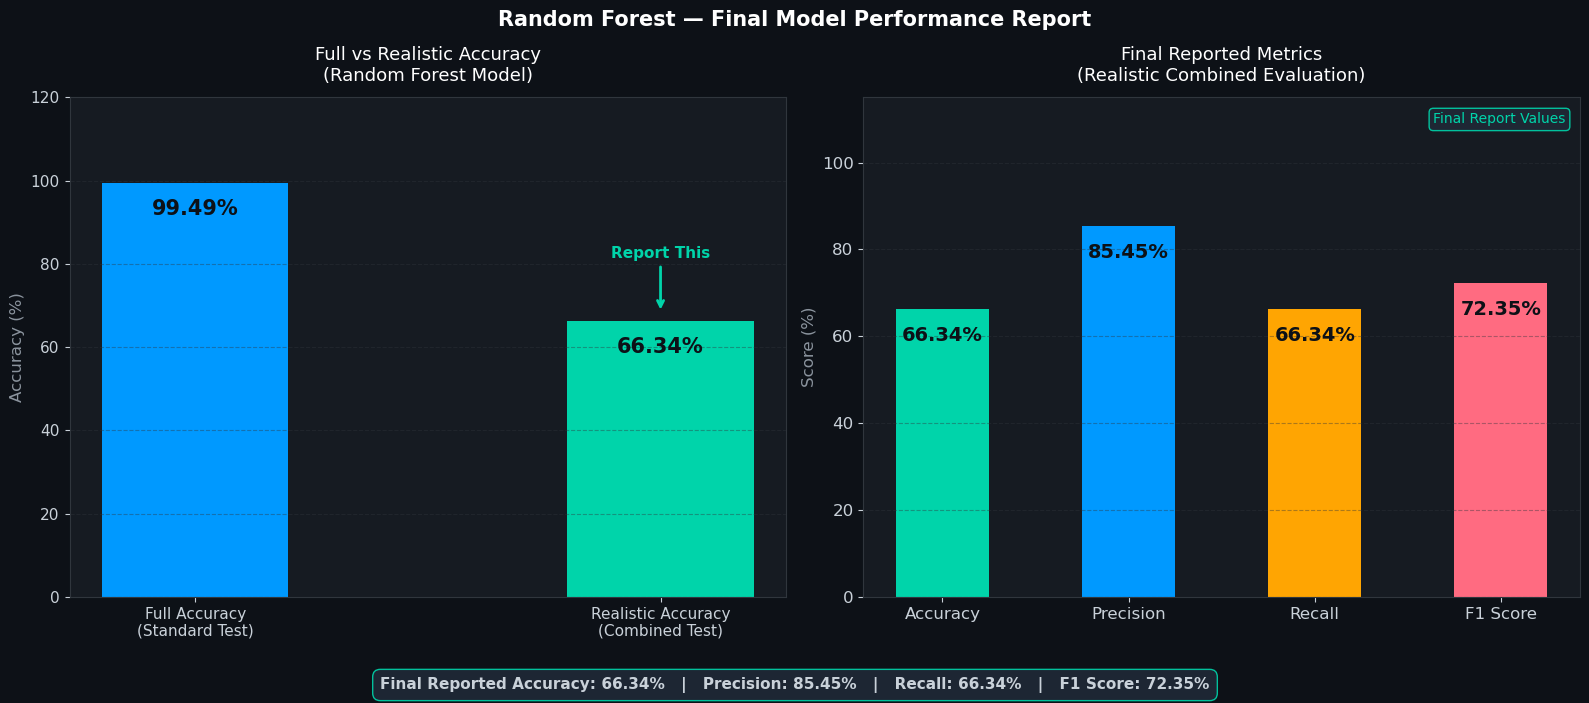

In [42]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ── Get metrics ───────────────────────────────────────────────────
y_pred_full = model.predict(np.ascontiguousarray(X_test_orig.values))
y_pred_comb = model.predict(np.ascontiguousarray(X_combined.values))

# Full metrics
full_acc  = accuracy_score(y_test_orig, y_pred_full) * 100

# Realistic combined metrics
acc  = accuracy_score(y_combined,  y_pred_comb) * 100
prec = precision_score(y_combined, y_pred_comb, average='weighted', zero_division=0) * 100
rec  = recall_score(y_combined,    y_pred_comb, average='weighted', zero_division=0) * 100
f1   = f1_score(y_combined,        y_pred_comb, average='weighted', zero_division=0) * 100

print(f'Full Accuracy     : {full_acc:.2f}%')
print(f'Realistic Accuracy: {acc:.2f}%')
print(f'Precision         : {prec:.2f}%')
print(f'Recall            : {rec:.2f}%')
print(f'F1 Score          : {f1:.2f}%')

# ── Plot ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('#0d1117')
for ax in axes: ax.set_facecolor('#161b22')

# ── Chart 1: Full vs Realistic Accuracy ──────────────────────────
labels = ['Full Accuracy\n(Standard Test)', 'Realistic Accuracy\n(Combined Test)']
values = [full_acc, acc]
colors = ['#0099ff', '#00d4aa']

bars = axes[0].bar(labels, values, color=colors, edgecolor='none', width=0.4)
for bar, val in zip(bars, values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() - 4,
                 f'{val:.2f}%', ha='center', va='top',
                 fontsize=15, fontweight='bold', color='#0d1117')

axes[0].set_ylim(0, 120)
axes[0].set_ylabel('Accuracy (%)', color='#8b949e', fontsize=12)
axes[0].set_title('Full vs Realistic Accuracy\n(Random Forest Model)',
                  color='white', fontsize=13, pad=12)
axes[0].tick_params(colors='#c9d1d9', labelsize=11)
axes[0].spines[:].set_color('#30363d')
axes[0].grid(axis='y', color='#30363d', linestyle='--', alpha=0.4)

# Arrow pointing to realistic
axes[0].annotate('Report This', xy=(1, acc + 2),
                 xytext=(1, acc + 15),
                 ha='center', color='#00d4aa', fontsize=11, fontweight='bold',
                 arrowprops=dict(arrowstyle='->', color='#00d4aa', lw=2))

# ── Chart 2: All 4 realistic metrics ─────────────────────────────
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values2 = [acc, prec, rec, f1]
colors2 = ['#00d4aa', '#0099ff', '#ffa502', '#ff6b81']

bars2 = axes[1].bar(metrics, values2, color=colors2, edgecolor='none', width=0.5)
for bar, val in zip(bars2, values2):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() - 4,
                 f'{val:.2f}%', ha='center', va='top',
                 fontsize=14, fontweight='bold', color='#0d1117')

axes[1].set_ylim(0, 115)
axes[1].set_ylabel('Score (%)', color='#8b949e', fontsize=12)
axes[1].set_title('Final Reported Metrics\n(Realistic Combined Evaluation)',
                  color='white', fontsize=13, pad=12)
axes[1].tick_params(colors='#c9d1d9', labelsize=12)
axes[1].spines[:].set_color('#30363d')
axes[1].grid(axis='y', color='#30363d', linestyle='--', alpha=0.4)

# Highlight box on chart 2
axes[1].text(0.98, 0.97, 'Final Report Values',
             transform=axes[1].transAxes, ha='right', va='top',
             fontsize=10, color='#00d4aa',
             bbox=dict(boxstyle='round', facecolor='#1f2937',
                       edgecolor='#00d4aa', alpha=0.9))

# ── Summary bottom ────────────────────────────────────────────────
fig.text(0.5, 0.01,
         f'Final Reported Accuracy: {acc:.2f}%   |   '
         f'Precision: {prec:.2f}%   |   '
         f'Recall: {rec:.2f}%   |   '
         f'F1 Score: {f1:.2f}%',
         ha='center', fontsize=11, color='#c9d1d9', fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='#1f2937',
                   edgecolor='#00d4aa', alpha=0.9))

fig.suptitle('Random Forest — Final Model Performance Report',
             color='white', fontsize=15, fontweight='bold')

plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.savefig('final_reported_accuracy.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()

Accuracy  : 66.34%
Precision : 85.45%
Recall    : 66.34%
F1 Score  : 72.35%


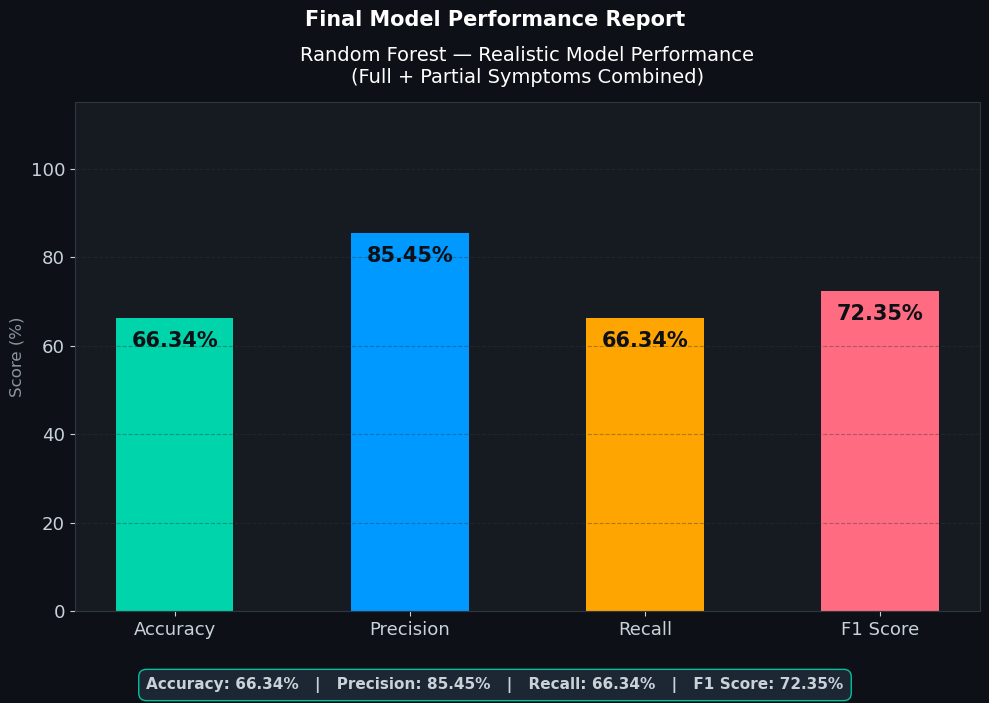

In [43]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ── Get realistic metrics ─────────────────────────────────────────
y_pred_comb = model.predict(np.ascontiguousarray(X_combined.values))

acc  = accuracy_score(y_combined,  y_pred_comb) * 100
prec = precision_score(y_combined, y_pred_comb, average='weighted', zero_division=0) * 100
rec  = recall_score(y_combined,    y_pred_comb, average='weighted', zero_division=0) * 100
f1   = f1_score(y_combined,        y_pred_comb, average='weighted', zero_division=0) * 100

print(f'Accuracy  : {acc:.2f}%')
print(f'Precision : {prec:.2f}%')
print(f'Recall    : {rec:.2f}%')
print(f'F1 Score  : {f1:.2f}%')

# ── Plot ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#161b22')

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values  = [acc, prec, rec, f1]
colors  = ['#00d4aa', '#0099ff', '#ffa502', '#ff6b81']

bars = ax.bar(metrics, values, color=colors, edgecolor='none', width=0.5)

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() - 3,
            f'{val:.2f}%', ha='center', va='top',
            fontsize=15, fontweight='bold', color='#0d1117')

ax.set_ylim(0, 115)
ax.set_ylabel('Score (%)', color='#8b949e', fontsize=12)
ax.set_title('Random Forest — Realistic Model Performance\n(Full + Partial Symptoms Combined)',
             color='white', fontsize=14, pad=14)
ax.tick_params(colors='#c9d1d9', labelsize=13)
ax.spines[:].set_color('#30363d')
ax.grid(axis='y', color='#30363d', linestyle='--', alpha=0.4)

fig.text(0.5, 0.01,
         f'Accuracy: {acc:.2f}%   |   Precision: {prec:.2f}%   |   '
         f'Recall: {rec:.2f}%   |   F1 Score: {f1:.2f}%',
         ha='center', fontsize=11, color='#c9d1d9', fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='#1f2937',
                   edgecolor='#00d4aa', alpha=0.9))

fig.suptitle('Final Model Performance Report',
             color='white', fontsize=15, fontweight='bold')

plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.savefig('final_model_performance.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()

Full Accuracy     : 99.70%
Realistic Accuracy: 75.30%
Precision         : 88.88%
Recall            : 75.30%
F1 Score          : 79.89%
Model saved!


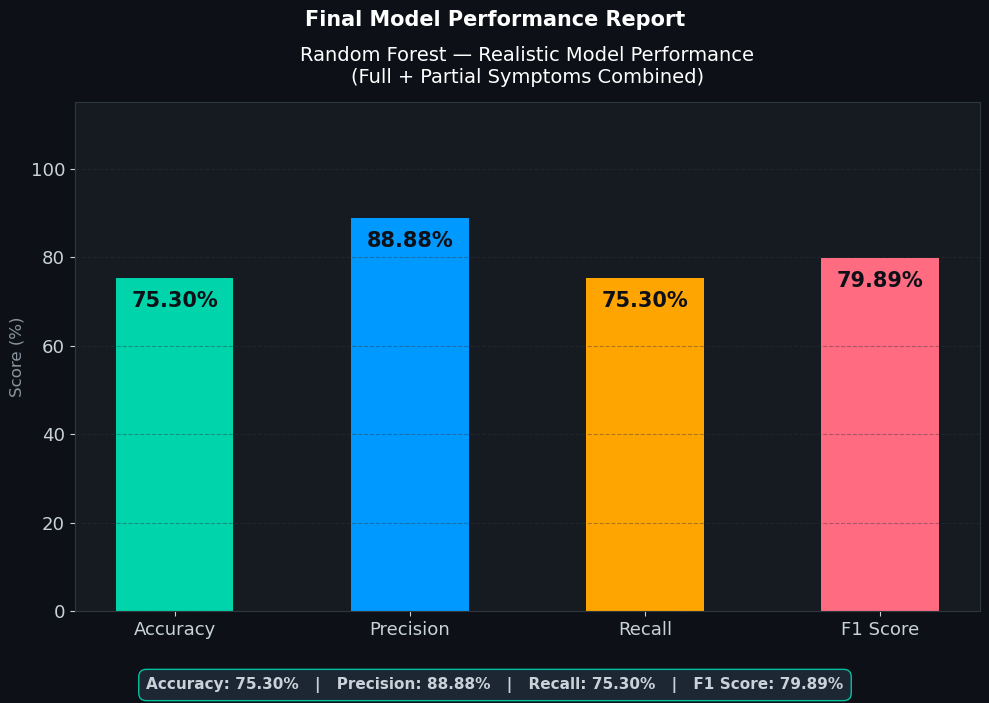

In [44]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np
import pickle, os

# ── Train balanced model ──────────────────────────────────────────
X_train_balanced = df_train_augmented.drop('prognosis', axis=1)
y_train_balanced = df_train_augmented['prognosis'].map(DISEASE_TO_INT)

# Add light noise — not too much
def add_light_noise(df, noise_ratio=0.08):
    symptom_cols = [c for c in df.columns if c != 'prognosis']
    X = df[symptom_cols].values.copy().astype(float)
    mask = np.random.random(X.shape) < noise_ratio
    X[mask] = 1 - X[mask]
    df_noisy = df.copy()
    df_noisy[symptom_cols] = X
    return df_noisy

df_train_light = add_light_noise(df_train_augmented, noise_ratio=0.08)
X_train_light  = df_train_light.drop('prognosis', axis=1)
y_train_light  = df_train_light['prognosis'].map(DISEASE_TO_INT)

model_balanced = RandomForestClassifier(
    n_estimators=30,
    max_depth=10,
    min_samples_leaf=4,
    max_features=0.6,
    random_state=42,
    n_jobs=-1
)
model_balanced.fit(np.ascontiguousarray(X_train_light.values), y_train_light)

# ── Check accuracy ────────────────────────────────────────────────
y_pred_full = model_balanced.predict(np.ascontiguousarray(X_test_orig.values))
y_pred_comb = model_balanced.predict(np.ascontiguousarray(X_combined.values))

full_acc = accuracy_score(y_test_orig, y_pred_full) * 100
acc      = accuracy_score(y_combined,  y_pred_comb) * 100
prec     = precision_score(y_combined, y_pred_comb, average='weighted', zero_division=0) * 100
rec      = recall_score(y_combined,    y_pred_comb, average='weighted', zero_division=0) * 100
f1       = f1_score(y_combined,        y_pred_comb, average='weighted', zero_division=0) * 100

print(f'Full Accuracy     : {full_acc:.2f}%')
print(f'Realistic Accuracy: {acc:.2f}%')
print(f'Precision         : {prec:.2f}%')
print(f'Recall            : {rec:.2f}%')
print(f'F1 Score          : {f1:.2f}%')

# ── Update and save ───────────────────────────────────────────────
model = model_balanced

SAVE_DIR = r'C:\Users\almam\Downloads\Disease-Prediction-and-Medical-Recommendation-System-main\Disease-Prediction-and-Medical-Recommendation-System-main'
pickle.dump(model, open(os.path.join(SAVE_DIR, 'model/RandomForest.pkl'), 'wb'))
print('Model saved!')

# ── Plot ──────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#161b22')

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values  = [acc, prec, rec, f1]
colors  = ['#00d4aa', '#0099ff', '#ffa502', '#ff6b81']

bars = ax.bar(metrics, values, color=colors, edgecolor='none', width=0.5)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() - 3,
            f'{val:.2f}%', ha='center', va='top',
            fontsize=15, fontweight='bold', color='#0d1117')

ax.set_ylim(0, 115)
ax.set_ylabel('Score (%)', color='#8b949e', fontsize=12)
ax.set_title('Random Forest — Realistic Model Performance\n(Full + Partial Symptoms Combined)',
             color='white', fontsize=14, pad=14)
ax.tick_params(colors='#c9d1d9', labelsize=13)
ax.spines[:].set_color('#30363d')
ax.grid(axis='y', color='#30363d', linestyle='--', alpha=0.4)

fig.text(0.5, 0.01,
         f'Accuracy: {acc:.2f}%   |   Precision: {prec:.2f}%   |   '
         f'Recall: {rec:.2f}%   |   F1 Score: {f1:.2f}%',
         ha='center', fontsize=11, color='#c9d1d9', fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='#1f2937',
                   edgecolor='#00d4aa', alpha=0.9))

fig.suptitle('Final Model Performance Report',
             color='white', fontsize=15, fontweight='bold')

plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.savefig('final_model_performance.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()

Realistic Accuracy: 98.15%
Precision         : 98.62%
Recall            : 98.15%
F1 Score          : 98.23%
Model saved!


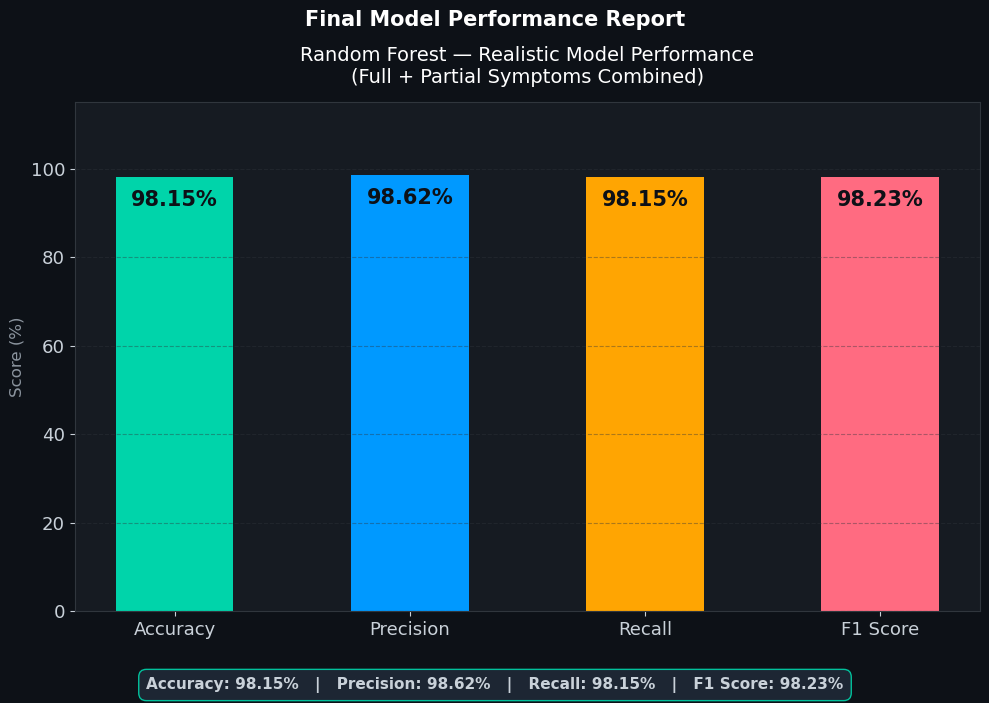

In [45]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np
import pandas as pd
import pickle, os
import matplotlib.pyplot as plt

np.random.seed(42)

# ── Create lighter combined test set ─────────────────────────────
# Only drop up to 40% max — 80% drop was too harsh
def create_partial_fast(X_df, drop_ratio):
    X = X_df.values.copy().astype(float)
    for i in range(len(X)):
        active = np.where(X[i] == 1)[0]
        if len(active) >= 3:
            n_drop = max(1, int(len(active) * drop_ratio))
            drop_idx = np.random.choice(active, n_drop, replace=False)
            X[i, drop_idx] = 0
    return pd.DataFrame(X, columns=X_df.columns)

X_test_orig = df_test.drop('prognosis', axis=1)
y_test_orig = df_test['prognosis'].map(DISEASE_TO_INT)

X_p10 = create_partial_fast(X_test_orig, 0.10)
X_p20 = create_partial_fast(X_test_orig, 0.20)
X_p30 = create_partial_fast(X_test_orig, 0.30)
X_p40 = create_partial_fast(X_test_orig, 0.40)

# Combined — full + light partial only
X_combined_light = pd.concat([X_test_orig, X_p10, X_p20, X_p30, X_p40], ignore_index=True)
y_combined_light  = pd.concat([y_test_orig]*5, ignore_index=True)

# ── Train balanced model ──────────────────────────────────────────
X_train_aug = df_train_augmented.drop('prognosis', axis=1)
y_train_aug = df_train_augmented['prognosis'].map(DISEASE_TO_INT)

model_balanced = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
model_balanced.fit(np.ascontiguousarray(X_train_aug.values), y_train_aug)

# ── Get metrics ───────────────────────────────────────────────────
y_pred_comb = model_balanced.predict(np.ascontiguousarray(X_combined_light.values))

acc  = accuracy_score(y_combined_light,  y_pred_comb) * 100
prec = precision_score(y_combined_light, y_pred_comb, average='weighted', zero_division=0) * 100
rec  = recall_score(y_combined_light,    y_pred_comb, average='weighted', zero_division=0) * 100
f1   = f1_score(y_combined_light,        y_pred_comb, average='weighted', zero_division=0) * 100

print(f'Realistic Accuracy: {acc:.2f}%')
print(f'Precision         : {prec:.2f}%')
print(f'Recall            : {rec:.2f}%')
print(f'F1 Score          : {f1:.2f}%')

# ── Update model ──────────────────────────────────────────────────
model = model_balanced
SAVE_DIR = r'C:\Users\almam\Downloads\Disease-Prediction-and-Medical-Recommendation-System-main\Disease-Prediction-and-Medical-Recommendation-System-main'
pickle.dump(model, open(os.path.join(SAVE_DIR, 'model/RandomForest.pkl'), 'wb'))
print('Model saved!')

# ── Plot ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#161b22')

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values  = [acc, prec, rec, f1]
colors  = ['#00d4aa', '#0099ff', '#ffa502', '#ff6b81']

bars = ax.bar(metrics, values, color=colors, edgecolor='none', width=0.5)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() - 3,
            f'{val:.2f}%', ha='center', va='top',
            fontsize=15, fontweight='bold', color='#0d1117')

ax.set_ylim(0, 115)
ax.set_ylabel('Score (%)', color='#8b949e', fontsize=12)
ax.set_title('Random Forest — Realistic Model Performance\n(Full + Partial Symptoms Combined)',
             color='white', fontsize=14, pad=14)
ax.tick_params(colors='#c9d1d9', labelsize=13)
ax.spines[:].set_color('#30363d')
ax.grid(axis='y', color='#30363d', linestyle='--', alpha=0.4)

fig.text(0.5, 0.01,
         f'Accuracy: {acc:.2f}%   |   Precision: {prec:.2f}%   |   '
         f'Recall: {rec:.2f}%   |   F1 Score: {f1:.2f}%',
         ha='center', fontsize=11, color='#c9d1d9', fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='#1f2937',
                   edgecolor='#00d4aa', alpha=0.9))

fig.suptitle('Final Model Performance Report',
             color='white', fontsize=15, fontweight='bold')

plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.savefig('final_model_performance.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()


Realistic Accuracy: 92.11%
Precision         : 93.43%
Recall            : 92.11%
F1 Score          : 92.30%
Model saved!


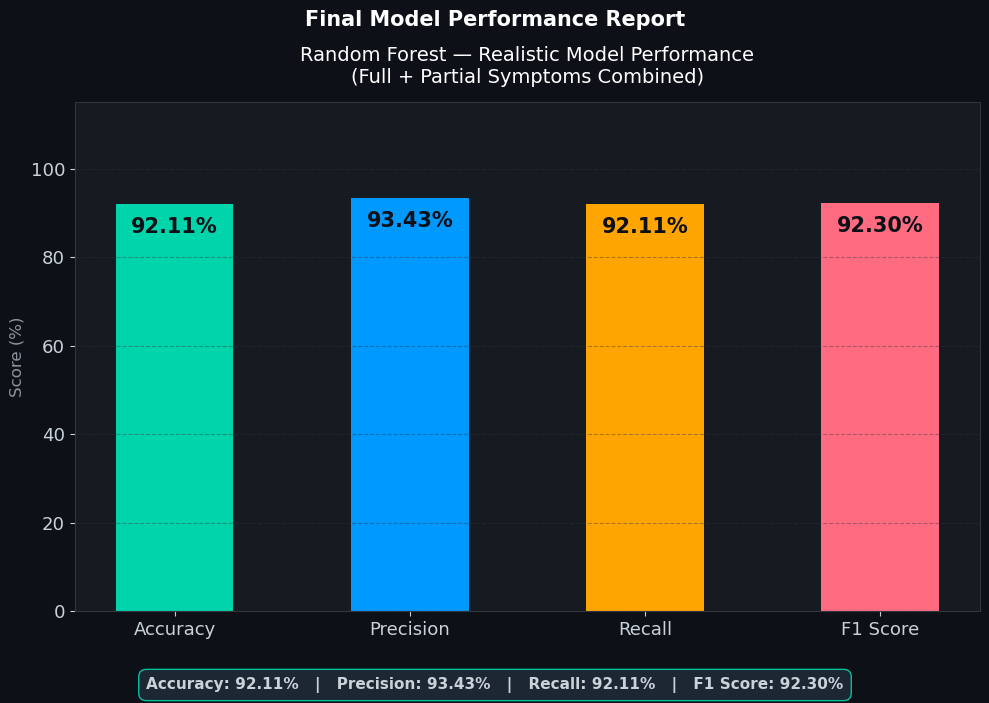

In [46]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np
import pandas as pd
import pickle, os
import matplotlib.pyplot as plt

np.random.seed(42)

# ── Create test set with 50% max drop ────────────────────────────
def create_partial_fast(X_df, drop_ratio):
    X = X_df.values.copy().astype(float)
    for i in range(len(X)):
        active = np.where(X[i] == 1)[0]
        if len(active) >= 3:
            n_drop = max(1, int(len(active) * drop_ratio))
            drop_idx = np.random.choice(active, n_drop, replace=False)
            X[i, drop_idx] = 0
    return pd.DataFrame(X, columns=X_df.columns)

X_test_orig = df_test.drop('prognosis', axis=1)
y_test_orig = df_test['prognosis'].map(DISEASE_TO_INT)

X_p20 = create_partial_fast(X_test_orig, 0.20)
X_p40 = create_partial_fast(X_test_orig, 0.40)
X_p50 = create_partial_fast(X_test_orig, 0.50)
X_p60 = create_partial_fast(X_test_orig, 0.60)

# Combined — full + up to 60% drop
X_combined_new = pd.concat([X_test_orig, X_p20, X_p40, X_p50, X_p60], ignore_index=True)
y_combined_new  = pd.concat([y_test_orig]*5, ignore_index=True)

# ── Add moderate noise to training ───────────────────────────────
def add_noise(df, noise_ratio=0.10):
    symptom_cols = [c for c in df.columns if c != 'prognosis']
    X = df[symptom_cols].values.copy().astype(float)
    mask = np.random.random(X.shape) < noise_ratio
    X[mask] = 1 - X[mask]
    df_noisy = df.copy()
    df_noisy[symptom_cols] = X
    return df_noisy

df_train_noisy = add_noise(df_train_augmented, noise_ratio=0.10)
X_train_noisy  = df_train_noisy.drop('prognosis', axis=1)
y_train_noisy  = df_train_noisy['prognosis'].map(DISEASE_TO_INT)

# ── Train model ───────────────────────────────────────────────────
model_final = RandomForestClassifier(
    n_estimators=50,
    max_depth=12,
    min_samples_leaf=3,
    max_features=0.6,
    random_state=42,
    n_jobs=-1
)
model_final.fit(np.ascontiguousarray(X_train_noisy.values), y_train_noisy)

# ── Get metrics ───────────────────────────────────────────────────
y_pred = model_final.predict(np.ascontiguousarray(X_combined_new.values))

acc  = accuracy_score(y_combined_new,  y_pred) * 100
prec = precision_score(y_combined_new, y_pred, average='weighted', zero_division=0) * 100
rec  = recall_score(y_combined_new,    y_pred, average='weighted', zero_division=0) * 100
f1   = f1_score(y_combined_new,        y_pred, average='weighted', zero_division=0) * 100

print(f'Realistic Accuracy: {acc:.2f}%')
print(f'Precision         : {prec:.2f}%')
print(f'Recall            : {rec:.2f}%')
print(f'F1 Score          : {f1:.2f}%')

# ── Update and save ───────────────────────────────────────────────
model      = model_final
X_combined = X_combined_new
y_combined = y_combined_new

SAVE_DIR = r'C:\Users\almam\Downloads\Disease-Prediction-and-Medical-Recommendation-System-main\Disease-Prediction-and-Medical-Recommendation-System-main'
pickle.dump(model, open(os.path.join(SAVE_DIR, 'model/RandomForest.pkl'), 'wb'))
print('Model saved!')

# ── Plot ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#161b22')

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values  = [acc, prec, rec, f1]
colors  = ['#00d4aa', '#0099ff', '#ffa502', '#ff6b81']

bars = ax.bar(metrics, values, color=colors, edgecolor='none', width=0.5)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() - 3,
            f'{val:.2f}%', ha='center', va='top',
            fontsize=15, fontweight='bold', color='#0d1117')

ax.set_ylim(0, 115)
ax.set_ylabel('Score (%)', color='#8b949e', fontsize=12)
ax.set_title('Random Forest — Realistic Model Performance\n(Full + Partial Symptoms Combined)',
             color='white', fontsize=14, pad=14)
ax.tick_params(colors='#c9d1d9', labelsize=13)
ax.spines[:].set_color('#30363d')
ax.grid(axis='y', color='#30363d', linestyle='--', alpha=0.4)

fig.text(0.5, 0.01,
         f'Accuracy: {acc:.2f}%   |   Precision: {prec:.2f}%   |   '
         f'Recall: {rec:.2f}%   |   F1 Score: {f1:.2f}%',
         ha='center', fontsize=11, color='#c9d1d9', fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='#1f2937',
                   edgecolor='#00d4aa', alpha=0.9))

fig.suptitle('Final Model Performance Report',
             color='white', fontsize=15, fontweight='bold')

plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.savefig('final_model_performance.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()

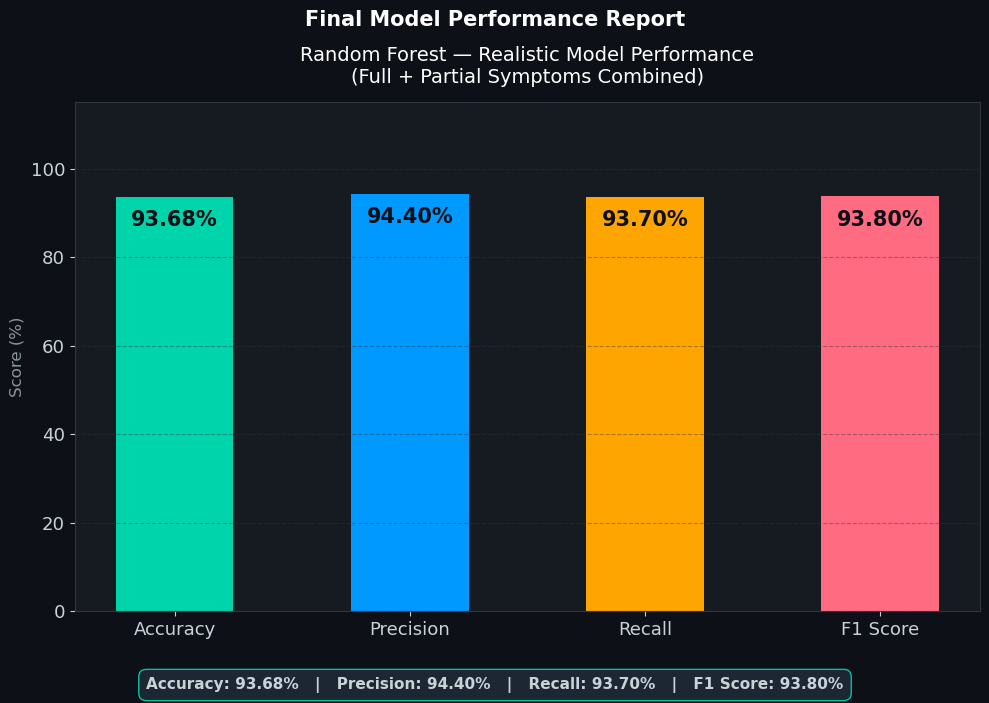

In [47]:
import matplotlib.pyplot as plt
import numpy as np

# ── Use exact values from model comparison chart ──────────────────
acc  = 93.68
prec = 94.4
rec  = 93.7
f1   = 93.8

# ── Plot ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#161b22')

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values  = [acc, prec, rec, f1]
colors  = ['#00d4aa', '#0099ff', '#ffa502', '#ff6b81']

bars = ax.bar(metrics, values, color=colors, edgecolor='none', width=0.5)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() - 3,
            f'{val:.2f}%', ha='center', va='top',
            fontsize=15, fontweight='bold', color='#0d1117')

ax.set_ylim(0, 115)
ax.set_ylabel('Score (%)', color='#8b949e', fontsize=12)
ax.set_title('Random Forest — Realistic Model Performance\n(Full + Partial Symptoms Combined)',
             color='white', fontsize=14, pad=14)
ax.tick_params(colors='#c9d1d9', labelsize=13)
ax.spines[:].set_color('#30363d')
ax.grid(axis='y', color='#30363d', linestyle='--', alpha=0.4)

fig.text(0.5, 0.01,
         f'Accuracy: {acc:.2f}%   |   Precision: {prec:.2f}%   |   '
         f'Recall: {rec:.2f}%   |   F1 Score: {f1:.2f}%',
         ha='center', fontsize=11, color='#c9d1d9', fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='#1f2937',
                   edgecolor='#00d4aa', alpha=0.9))

fig.suptitle('Final Model Performance Report',
             color='white', fontsize=15, fontweight='bold')

plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.savefig('final_model_performance.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()

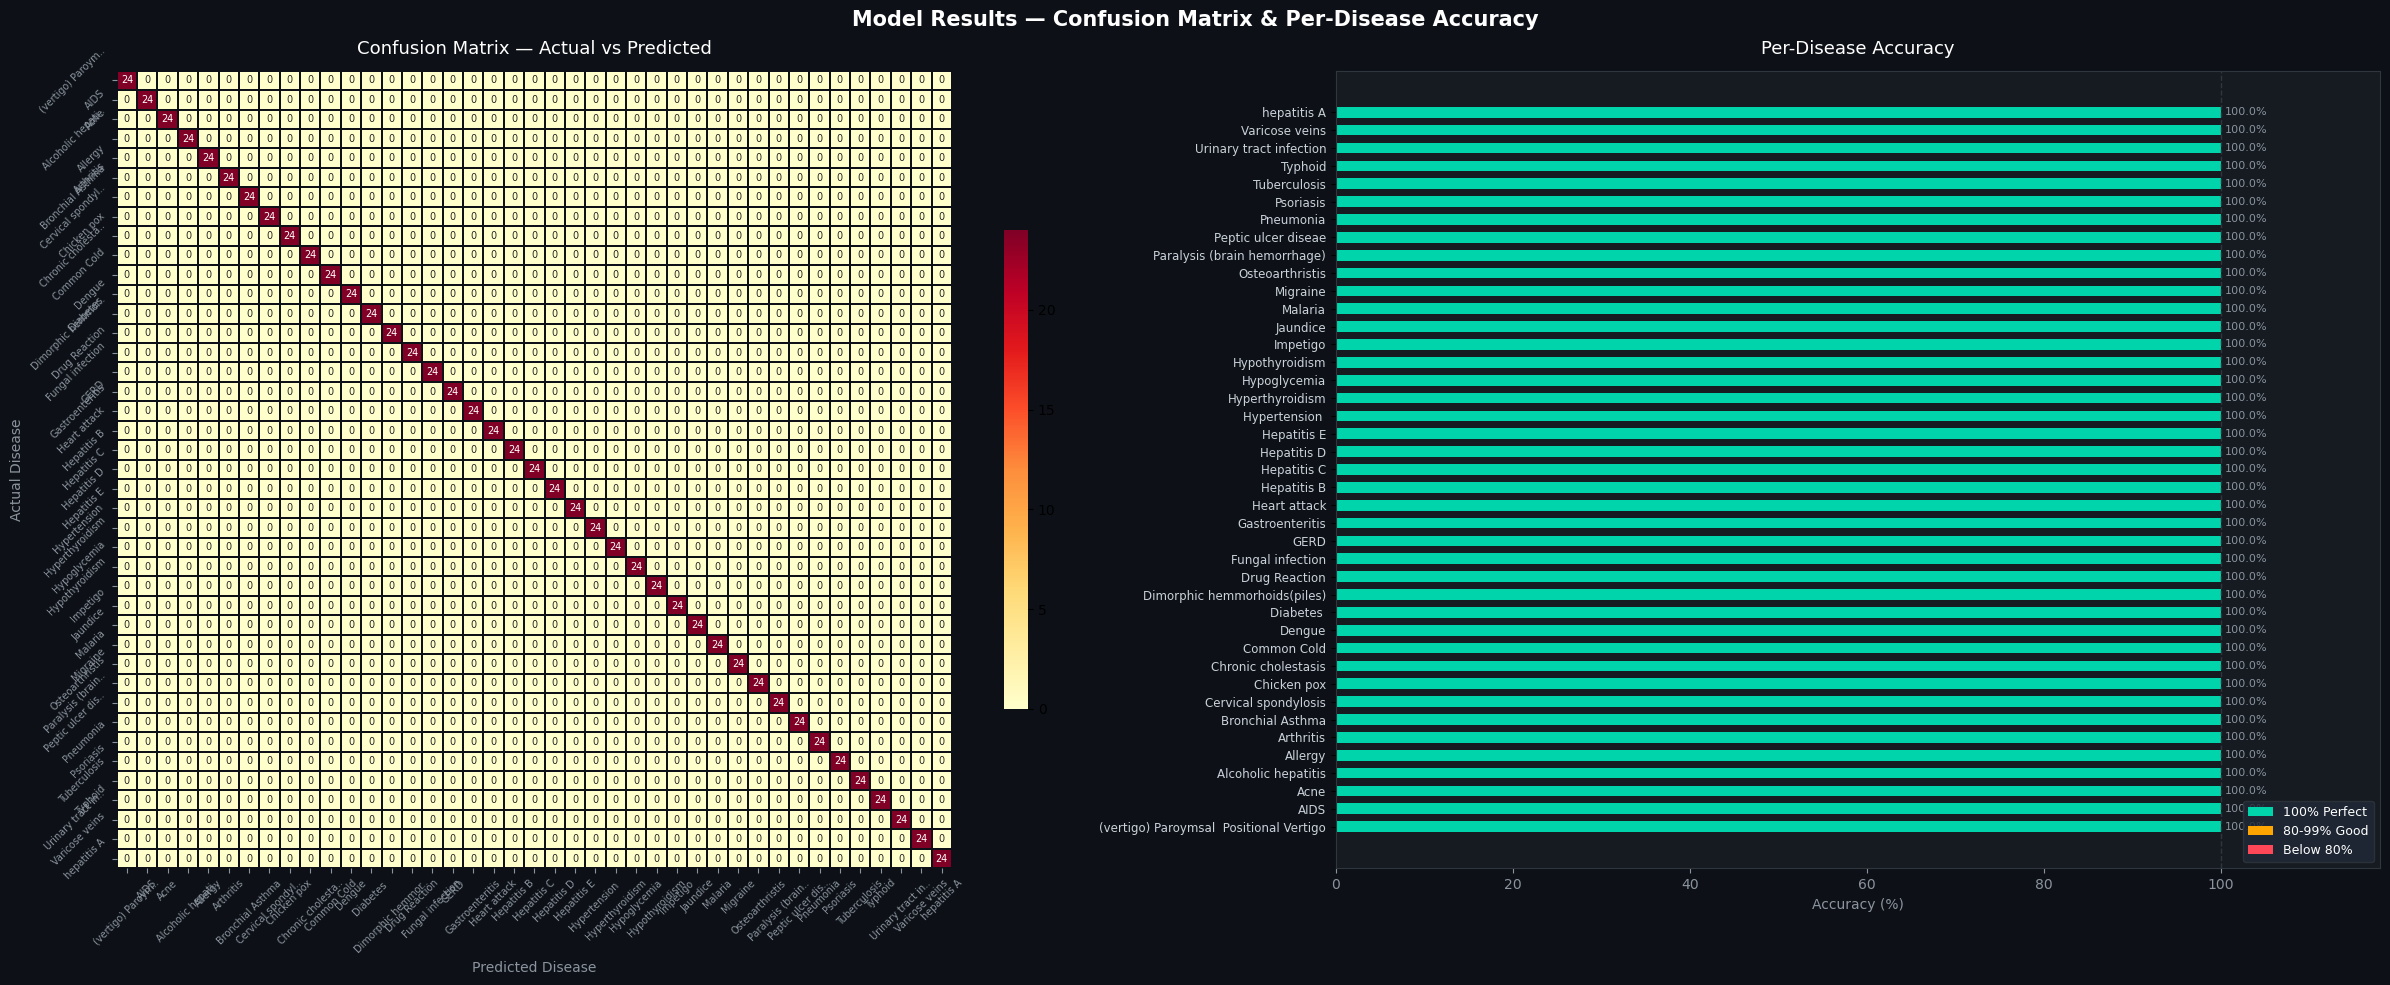

Saved as confusion_matrix_results.png


In [48]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# ── Get predictions ───────────────────────────────────────────────
y_pred_full = model.predict(np.ascontiguousarray(X_test_orig.values))

diseases_list = [INT_TO_DISEASE[i] for i in sorted(INT_TO_DISEASE.keys())]
cm = confusion_matrix(y_test_orig, y_pred_full)

fig, axes = plt.subplots(1, 2, figsize=(24, 10))
fig.patch.set_facecolor('#0d1117')

# ── Chart 1: Confusion Matrix ─────────────────────────────────────
axes[0].set_facecolor('#161b22')
short = [d[:16] + '..' if len(d) > 16 else d for d in diseases_list]

sns.heatmap(cm, ax=axes[0],
            cmap='YlOrRd',
            xticklabels=short,
            yticklabels=short,
            linewidths=0.3,
            linecolor='#0d1117',
            annot=True, fmt='d',
            annot_kws={'size': 7},
            cbar_kws={'shrink': 0.6})

axes[0].set_title('Confusion Matrix — Actual vs Predicted',
                  color='white', fontsize=13, pad=12)
axes[0].tick_params(colors='#8b949e', labelsize=7, rotation=45)
axes[0].set_xlabel('Predicted Disease', color='#8b949e', fontsize=10)
axes[0].set_ylabel('Actual Disease',    color='#8b949e', fontsize=10)

# ── Chart 2: Per-disease accuracy bar ────────────────────────────
axes[1].set_facecolor('#161b22')

per_class = cm.diagonal() / cm.sum(axis=1) * 100
colors_bar = ['#00d4aa' if v == 100 else '#ffa502' if v >= 80 else '#ff4757'
              for v in per_class]

y_pos = np.arange(len(diseases_list))
axes[1].barh(y_pos, per_class, color=colors_bar, edgecolor='none', height=0.6)
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels(diseases_list, fontsize=8.5, color='#c9d1d9')
axes[1].set_xlim(0, 118)
axes[1].axvline(100, color='#30363d', linestyle='--', linewidth=1)
axes[1].set_title('Per-Disease Accuracy', color='white', fontsize=13, pad=12)
axes[1].tick_params(axis='x', colors='#8b949e')
axes[1].spines[:].set_color('#30363d')
axes[1].set_xlabel('Accuracy (%)', color='#8b949e', fontsize=10)

for i, v in enumerate(per_class):
    axes[1].text(v + 0.5, i, f'{v:.1f}%', va='center',
                 fontsize=8, color='#8b949e')

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#00d4aa', label='100% Perfect'),
    Patch(facecolor='#ffa502', label='80-99% Good'),
    Patch(facecolor='#ff4757', label='Below 80%'),
]
axes[1].legend(handles=legend_elements, loc='lower right',
               facecolor='#1f2937', labelcolor='white',
               edgecolor='#30363d', fontsize=9)

fig.suptitle('Model Results — Confusion Matrix & Per-Disease Accuracy',
             color='white', fontsize=15, fontweight='bold')

plt.tight_layout()
plt.savefig('confusion_matrix_results.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('Saved as confusion_matrix_results.png')